In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [ ]:
"""
SQuAD Answer Generation with GloVe Embeddings + Q/K Hypothesis Testing
"""

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from transformers import GPT2Tokenizer

import json
from collections import Counter
import string
import re
from tqdm import tqdm
import numpy as np
import os
import urllib.request
import zipfile
import torch.nn.functional as F



# Optimized for GloVe embeddings
D_MODEL = 300  # Match GloVe dimension exactly
N_HEADS = 6
N_LAYERS = 6
D_FF = 1200
MAX_SEQ_LEN = 256
MAX_ANSWER_LEN = 50



def download_and_extract_glove():
    """Download and extract GloVe embeddings"""
    glove_file = 'glove.6B.300d.txt'

    if os.path.exists(glove_file):
        print(f"✓ GloVe embeddings found: {glove_file}")
        return glove_file

    print("\n" + "="*70)
    print("DOWNLOADING GLOVE EMBEDDINGS")
    print("="*70)

    zip_file = 'glove.6B.zip'

    if not os.path.exists(zip_file):
        print("Downloading GloVe 6B (822MB)... This may take a few minutes")
        url = 'https://huggingface.co/stanfordnlp/glove/resolve/main/glove.6B.zip'

        try:
            # Download with progress bar
            response = urllib.request.urlopen(url)
            total_size = int(response.headers.get('content-length', 0))

            with open(zip_file, 'wb') as f, tqdm(
                total=total_size, unit='B', unit_scale=True, desc='Downloading'
            ) as pbar:
                while True:
                    chunk = response.read(8192)
                    if not chunk:
                        break
                    f.write(chunk)
                    pbar.update(len(chunk))

            print("✓ Download complete!")
        except Exception as e:
            print(f"Download failed: {e}")
            print("\nAlternative: Download manually from:")
            print("  https://nlp.stanford.edu/projects/glove/")
            print("  or https://huggingface.co/stanfordnlp/glove")
            return None

    # Extract
    if os.path.exists(zip_file):
        print("Extracting GloVe embeddings...")
        with zipfile.ZipFile(zip_file, 'r') as zip_ref:
            # Only extract the 300d file we need
            zip_ref.extract('glove.6B.300d.txt')
        print("✓ Extraction complete!")

        # Optionally remove zip to save space
        # os.remove(zip_file)

    if os.path.exists(glove_file):
        return glove_file
    else:
        print("⚠ GloVe file not found after extraction")
        return None


def load_glove_embeddings(glove_file, tokenizer, embedding_dim=300):
    """Load GloVe and create embedding matrix for GPT-2 tokenizer"""
    print("\n" + "="*70)
    print("LOADING GLOVE EMBEDDINGS")
    print("="*70)

    # Load GloVe vectors
    print("Reading GloVe file (this takes ~1 minute)...")
    glove_vectors = {}

    with open(glove_file, 'r', encoding='utf-8') as f:
        for line in tqdm(f, total=400000, desc="Loading GloVe"):
            values = line.rstrip().split(' ')
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            glove_vectors[word] = vector

    print(f"✓ Loaded {len(glove_vectors):,} GloVe vectors")

    # Create embedding matrix for tokenizer vocabulary
    vocab_size = tokenizer.vocab_size
    embedding_matrix = np.random.normal(0, 0.1, (vocab_size, embedding_dim)).astype('float32')

    # Match tokenizer vocab with GloVe
    print("Matching tokenizer vocabulary with GloVe...")
    matched = 0

    for token, idx in tqdm(tokenizer.get_vocab().items(), desc="Matching"):
        # Try different matching strategies
        token_clean = token.replace('Ġ', '').replace('Ċ', '').lower().strip()

        if token in glove_vectors:
            embedding_matrix[idx] = glove_vectors[token]
            matched += 1
        elif token.lower() in glove_vectors:
            embedding_matrix[idx] = glove_vectors[token.lower()]
            matched += 1
        elif token_clean in glove_vectors:
            embedding_matrix[idx] = glove_vectors[token_clean]
            matched += 1
        # For subword tokens, try averaging character embeddings
        elif len(token_clean) > 0 and all(c.isalpha() for c in token_clean):
            # Use random but consistent embedding for unknown tokens
            pass

    match_rate = 100 * matched / vocab_size
    print(f"✓ Matched {matched:,}/{vocab_size:,} tokens ({match_rate:.1f}%)")
    print("="*70 + "\n")

    return torch.FloatTensor(embedding_matrix)


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_k = d_model // n_heads
        self.n_heads = n_heads

        self.q_linear = nn.Linear(d_model, d_model)
        self.k_linear = nn.Linear(d_model, d_model)
        self.v_linear = nn.Linear(d_model, d_model)
        self.out = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
        self.last_attention_weights = None

    def forward(self, q, k, v, mask=None, save_attention=False):
        bs = q.size(0)

        q = self.q_linear(q).view(bs, -1, self.n_heads, self.d_k).transpose(1, 2)
        k = self.k_linear(k).view(bs, -1, self.n_heads, self.d_k).transpose(1, 2)
        v = self.v_linear(v).view(bs, -1, self.n_heads, self.d_k).transpose(1, 2)

        scores = torch.matmul(q, k.transpose(-2, -1)) / (self.d_k ** 0.5)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attn = torch.softmax(scores, dim=-1)
        if save_attention:
            self.last_attention_weights = attn.detach()

        attn = self.dropout(attn)
        context = torch.matmul(attn, v)
        context = context.transpose(1, 2).contiguous().view(bs, -1, self.n_heads * self.d_k)

        return self.out(context)


class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x, mask=None, save_attention=False):
        # Pre-norm
        attn_out = self.self_attn(self.norm1(x), self.norm1(x), self.norm1(x), mask, save_attention)
        x = x + attn_out
        x = x + self.ff(self.norm2(x))
        return x


class GPTAnswerGenerator(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers, d_ff, max_seq_len,
                 dropout=0.1, pretrained_embeddings=None):
        super().__init__()

        self.token_embedding = nn.Embedding(vocab_size, d_model)

        # Initialize with pretrained embeddings if provided
        if pretrained_embeddings is not None:
            print("Initializing token embeddings with GloVe...")
            self.token_embedding.weight.data.copy_(pretrained_embeddings)
            print("✓ Token embeddings initialized with GloVe")

        self.position_embedding = nn.Embedding(max_seq_len, d_model)
        self.emb_dropout = nn.Dropout(dropout)

        self.layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])

        self.norm = nn.LayerNorm(d_model)
        self.output = nn.Linear(d_model, vocab_size)

        # Weight tying
        self.output.weight = self.token_embedding.weight

        # Initialize non-embedding weights
        self._init_weights()

    def _init_weights(self):
        # Don't reinitialize token_embedding if using GloVe
        for name, p in self.named_parameters():
            if 'token_embedding' not in name and p.dim() > 1:
                nn.init.xavier_uniform_(p, gain=1/np.sqrt(2))

    def forward(self, x, mask=None, save_attention=False):
        pos = torch.arange(x.size(1), device=x.device).unsqueeze(0)
        x = self.token_embedding(x) + self.position_embedding(pos)
        x = self.emb_dropout(x)

        for layer in self.layers:
            x = layer(x, mask, save_attention)

        return self.output(self.norm(x))

    def get_attention_weights(self):
        return [layer.self_attn.last_attention_weights for layer in self.layers]





def create_mask(seq_len, device):
    return (torch.triu(torch.ones(seq_len, seq_len, device=device), 1) == 0).unsqueeze(0).unsqueeze(0)


def normalize_answer(s):
    s = s.lower()
    s = re.sub(r'\b(a|an|the)\b', ' ', s)
    s = ''.join(c for c in s if c not in string.punctuation)
    return ' '.join(s.split())


def f1_score(pred, truth):
    pred_tok = normalize_answer(pred).split()
    truth_tok = normalize_answer(truth).split()

    if not pred_tok or not truth_tok:
        return int(pred_tok == truth_tok)

    common = Counter(pred_tok) & Counter(truth_tok)
    if not common:
        return 0

    prec = sum(common.values()) / len(pred_tok)
    rec = sum(common.values()) / len(truth_tok)
    return 2 * prec * rec / (prec + rec)


def exact_match(pred, truth):
    return int(normalize_answer(pred) == normalize_answer(truth))



def generate(model, tokenizer, context, question, device, max_len=50):
    model.eval()

    prompt = f"Q: {question} C: {context} A:"
    ids = tokenizer.encode(prompt, max_length=MAX_SEQ_LEN-max_len-5,
                          truncation=True, add_special_tokens=False, return_tensors='pt').to(device)

    start_len = ids.size(1)

    with torch.no_grad():
        for _ in range(max_len):
            if ids.size(1) >= MAX_SEQ_LEN:
                break

            mask = create_mask(ids.size(1), device)
            logits = model(ids, mask)
            next_tok = logits[:, -1].argmax(-1, keepdim=True)
            ids = torch.cat([ids, next_tok], 1)

            if next_tok.item() == tokenizer.eos_token_id:
                break

    return tokenizer.decode(ids[0, start_len:], skip_special_tokens=True).strip()


def evaluate(model, dataset, tokenizer, device, n_samples=300):
    model.eval()
    f1_sum = em_sum = 0

    if isinstance(dataset, Subset):
        items = [dataset.dataset.data[dataset.indices[i]] for i in range(min(n_samples, len(dataset)))]
    else:
        items = dataset.data[:n_samples]

    for item in tqdm(items, desc="Eval"):
        pred = generate(model, tokenizer, item['context'], item['question'], device)
        f1_sum += f1_score(pred, item['answer'])
        em_sum += exact_match(pred, item['answer'])

    return {'f1': f1_sum / len(items), 'em': em_sum / len(items)}

In [ ]:
def load_squad_with_spans(data_path):
    class SQuADWithSpans:
        def __init__(self, data_path):
            self.data = []
            with open(data_path, 'r', encoding='utf-8') as f:
                squad = json.load(f)

            for article in squad['data']:
                for para in article['paragraphs']:
                    ctx = para['context']
                    for qa in para['qas']:
                        if (not qa.get('is_impossible', False)) and qa.get('answers'):
                            ans = qa['answers'][0]['text']
                            ans_start = qa['answers'][0]['answer_start']
                            ans_end = ans_start + len(ans)

                            start = max(0, ans_start - 200)
                            end = min(len(ctx), ans_end + 200)
                            focused_ctx = ctx[start:end]

                            adj_start = ans_start - start
                            adj_end = adj_start + len(ans)

                            self.data.append({
                                "context": focused_ctx,
                                "question": qa["question"],
                                "answer": ans,
                                "answer_start": adj_start,
                                "answer_end": adj_end
                            })

        def __len__(self):
            return len(self.data)

    return SQuADWithSpans(data_path)

In [ ]:
def get_answer_token_positions(context, answer_start, answer_end, tokenizer):
    tokens = tokenizer.tokenize(context)
    token_to_char = []
    pos = 0
    for tok in tokens:
        t = tok.replace("Ġ", " ").replace("Ċ", "\n")
        # find next occurrence after pos
        start = context.find(t.strip(), pos)
        if start == -1:
            start = pos
        end = start + len(t.strip())
        token_to_char.append((start, end))
        pos = end
    ans = []
    for i, (s, e) in enumerate(token_to_char):
        if not (e <= answer_start or s >= answer_end):
            ans.append(i)
    return ans

In [ ]:
!pwd

/content


In [ ]:
# Add this if not present
from transformers import GPT2TokenizerFast

In [ ]:
DEV_JSON = "dev-v2.0.json" #"dev-v2.0.json"
BASELINE_CKPT = """/content/best_baseline_1234.pt""" #"best_qk.pt"  #"best_baseline.pt"  #  "best_qk.pt"

DROPOUT = 0.2

print("Loading tokenizer...")
tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Loading dataset...")
val_dataset = load_squad_with_spans(DEV_JSON)
print(f"Loaded {len(val_dataset)} examples (focus spans included)")


glove_file = download_and_extract_glove()
pretrained_embeddings = load_glove_embeddings(glove_file, tokenizer, D_MODEL)

model_kwargs = dict(vocab_size=tokenizer.vocab_size,
                    d_model=D_MODEL, n_heads=N_HEADS,
                    n_layers=N_LAYERS, d_ff=D_FF,
                    max_seq_len=MAX_SEQ_LEN,
                    dropout=DROPOUT,pretrained_embeddings=pretrained_embeddings)


print("Initializing baseline model instance...")
baseline = GPTAnswerGenerator(**model_kwargs).to(device)
baseline_ckpt = torch.load(BASELINE_CKPT, map_location=device)
baseline.load_state_dict(baseline_ckpt["model"])
print("Baseline model loaded.")

Loading tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

Loading GloVe: 400001it [00:27, 14290.16it/s]                            


✓ Loaded 400,001 GloVe vectors
Matching tokenizer vocabulary with GloVe...


Matching: 100%|██████████| 50257/50257 [00:00<00:00, 429552.76it/s]

✓ Matched 43,058/50,257 tokens (85.7%)



Initializing baseline model instance...
Initializing token embeddings with GloVe...
✓ Token embeddings initialized with GloVe
Baseline model loaded.


In [ ]:
def generate_faithful(model, tokenizer, context, question, device, max_len=50):
    model.eval()

    prompt = f"Q: {question} C: {context} A:"
    ids = tokenizer.encode(
        prompt,
        max_length=MAX_SEQ_LEN - max_len - 5,
        truncation=True,
        add_special_tokens=False,
        return_tensors="pt"
    ).to(device)

    start_len = ids.size(1)
    attention_steps = []   # <-- store attentions for faithfulness
    prob_steps = []
    with torch.no_grad():
        for _ in range(max_len):
            if ids.size(1) >= MAX_SEQ_LEN:
                break

            mask = create_mask(ids.size(1), device)

            # run forward pass with attention stored internally
            outputs = model(ids, mask, save_attention=True)
            #prob_steps.append(F.softmax(outputs[0,-1]).max())
            prob_steps.append(F.softmax(outputs[0,-1], dim=-1).cpu().numpy())
            # extract layer-wise attention for this step
            # this must be implemented in your model: model.get_attention_weights()
            step_att = model.get_attention_weights()

            # convert to CPU numpy so it doesn't get deleted later
            attention_steps.append([att.cpu().numpy() for att in step_att])

            # greedy decode next token
            next_tok = outputs[:, -1].argmax(-1, keepdim=True)
            ids = torch.cat([ids, next_tok], 1)

            if next_tok.item() == tokenizer.eos_token_id:
                break

    # decode output answer
    generated = tokenizer.decode(ids[0, start_len:], skip_special_tokens=True).strip()



    return generated, attention_steps, prob_steps


In [ ]:
 def compute_prediction_score(model, tokenizer, context, question, gold_answer, device, max_answer_len=50):
    """
    Single prediction score per datapoint for the *correct* output.
    Computes mean probability assigned to each gold token under teacher forcing.
    Returns float in [0,1].
    """
    model.eval()
    prompt = f"Q: {question} C: {context} A:"

    prompt_ids = tokenizer.encode(
        prompt,
        max_length=MAX_SEQ_LEN - max_answer_len - 5,
        truncation=True,
        add_special_tokens=False,
        return_tensors="pt"
    ).to(device)

    gold_ids = tokenizer.encode(
        gold_answer,
        max_length=max_answer_len,
        truncation=True,
        add_special_tokens=False,
        return_tensors="pt"
    ).to(device)

    if gold_ids.numel() == 0:
        return 0.0

    # Teacher forcing: input = prompt + gold[:-1], target = gold
    if gold_ids.size(1) > 1:
        input_ids = torch.cat([prompt_ids, gold_ids[:, :-1]], dim=1)
    else:
        input_ids = prompt_ids

    target_ids = gold_ids[0]  # (T,)

    with torch.no_grad():
        mask = create_mask(input_ids.size(1), device)
        logits = model(input_ids, mask)  # (1, seq, vocab)

    # Logits position that predicts first gold token is after last prompt token
    start = prompt_ids.size(1) - 1
    pred_positions = torch.arange(start, start + target_ids.size(0), device=device)
    pred_positions = pred_positions.clamp(max=logits.size(1) - 1)

    probs = torch.softmax(logits[0, pred_positions, :], dim=-1)  # (T, vocab)
    token_probs = probs.gather(1, target_ids.unsqueeze(1)).squeeze(1)  # (T,)

    return float(token_probs.mean().item())


In [ ]:
def get_answer_token_positions(question, context, answer_start, answer_end, tokenizer_fast):
    """
    Extract all token positions corresponding to the answer in the prompt.
    """
    # Full prompt
    prompt = f"Q: {question} C: {context} A:"

    # Tokenize with offsets
    encoding = tokenizer_fast(prompt, add_special_tokens=False, return_offsets_mapping=True)

    # Answer span in the full prompt
    prefix_len = len(f"Q: {question} C: ")
    ans_start_in_prompt = prefix_len + answer_start
    ans_end_in_prompt = prefix_len + answer_end

    token_positions = []
    for idx, (start, end) in enumerate(encoding.offset_mapping):
        # If the token overlaps with the answer span, include it
        if end > ans_start_in_prompt and start < ans_end_in_prompt:
            token_positions.append(idx)

    return token_positions,encoding["input_ids"]




In [ ]:
def rollout_single_step(layer_attentions, alpha=0.5):
    """
    Compute rollout attention for a single generation step.
    Includes identity correction and per-layer normalization.
    """
    attentions = []
    for attn in layer_attentions:
        # Mean over heads
        if attn.ndim == 4:   # (batch, heads, seq, seq)
            attn = attn[0].mean(0)
        else:                # (heads, seq, seq)
            attn = attn.mean(0)

        # Add identity skip connection
        attn = alpha * attn + (1 - alpha) * np.eye(attn.shape[0])

        # Normalize rows
        attn = attn / (attn.sum(-1, keepdims=True) + 1e-12)
        attentions.append(attn)

    # Rollout: multiply attention matrices
    R = attentions[0]
    for attn in attentions[1:]:
        R = attn @ R

    # Final row normalization
    return R / (R.sum(-1, keepdims=True) + 1e-12)

def attention_mass(attention_steps, answer_positions, alpha=0.3):
    """
    Compute attention mass on answer positions using three methods:
    1. Rollout attention (compositional flow through layers)
    2. Layer-averaged attention (simple averaging across layers)
    3. Max pooling (strongest attention across any layer)

    Args:
        attention_steps: List of attention tensors per generation step
        answer_positions: List of token positions corresponding to the answer
        alpha: Weight for rollout identity connection (default 0.5)

    Returns:
        rollout_mass: Average rollout attention mass across steps
        layer_avg_mass: Average layer-averaged attention mass across steps
        max_pool_mass: Average max-pooled attention mass across steps
    """
    rollout_masses = []
    layer_avg_masses = []
    max_pool_masses = []

    # Per-layer attention mass (one list per layer)
    per_layer_masses = None


    attention_probs_rollout_steps = []
    for step_attn in attention_steps:
        # Valid answer positions for this step
        valid_positions = None

        # --- Method 1: Rollout Attention ---
        R = rollout_single_step(step_attn, alpha=alpha)
        p = R[-1]  # last-token distribution

        attention_probs_rollout_steps.append(p)
        valid_positions = [i for i in answer_positions if i < len(p)]
        if valid_positions:
            rollout_mass = sum(p[i] for i in valid_positions)
            rollout_masses.append(rollout_mass)

        # --- Method 2: Layer-Averaged Attention ---
        layer_attns = []
        for layer_attn in step_attn:
            if layer_attn.ndim == 4:  # (batch, heads, seq, seq)
                layer_attn = layer_attn[0].mean(0)  # Average over heads
            else:  # (heads, seq, seq)
                layer_attn = layer_attn.mean(0)
            layer_attns.append(layer_attn)


        # ----------------------

        # Initialize per-layer container once we know number of layers
        if per_layer_masses is None:
            per_layer_masses = [[] for _ in range(len(layer_attns))]

        # Per-layer attention mass (using each layer's last-token attention)
        if valid_positions:
            for li, la in enumerate(layer_attns):
                last_row = la[-1]
                per_layer_masses[li].append(sum(last_row[i] for i in valid_positions))

        # ----------------------

        # Average attention matrices across all layers
        avg_attn = np.mean(layer_attns, axis=0)  # (seq, seq)
        last_token_attn = avg_attn[-1]
        if valid_positions:
            layer_avg_mass = sum(last_token_attn[i] for i in valid_positions)
            layer_avg_masses.append(layer_avg_mass)

        # --- Method 3: Max Pooling Across Layers ---
        max_attn = np.maximum.reduce(layer_attns)  # (seq, seq)
        last_token_attn_max = max_attn[-1]
        if valid_positions:
            max_pool_mass = sum(last_token_attn_max[i] for i in valid_positions)
            max_pool_masses.append(max_pool_mass)

    rollout_mean = float(np.mean(rollout_masses)) if rollout_masses else 0.0
    layer_avg_mean = float(np.mean(layer_avg_masses)) if layer_avg_masses else 0.0
    max_pool_mean = float(np.mean(max_pool_masses)) if max_pool_masses else 0.0

    per_layer_means = [float(np.mean(v)) if v else 0.0 for v in (per_layer_masses or [])]


    return rollout_mean, layer_avg_mean, max_pool_mean, attention_probs_rollout_steps, per_layer_means


In [ ]:
import numpy as np
import torch

def compute_comprehensiveness_sufficiency(model, tokenizer, context, question, device,
                                         attn_steps, prob_steps, ids,
                                         rollout_attn_probs, k_percent=20):
    """
    Compute comprehensiveness and sufficiency for all generation steps.

    Comprehensiveness = f(x) - f(x\r:k%) [drop after removing top-k%]
    Sufficiency = f(x) - f(r:k%) [drop when keeping only top-k%]

    Args:
        model: The language model
        ids: Input token ids (list or tensor of shape [1, seq_len])
        prob_steps: Probability distributions from generation [list of (vocab_size,)]
        rollout_attn_probs: List of rollout attention probs per step [(seq_len,)]
        k_percent: Percentage of tokens to use for top-k

    Returns:
        comprehensiveness: Average over all steps
        sufficiency: Average over all steps
    """
    comprehensiveness_scores = []
    sufficiency_scores = []



    # Convert ids to tensor if it's a list
    if isinstance(ids, list):
        ids = torch.tensor([ids], device=device)

    # For each generation step
    for step in range(len(rollout_attn_probs)):
        # Get the token generated at this step
        step_probs = prob_steps[step]  # Shape: (vocab_size,)
        #print(step_probs)
        generated_token_id = np.argmax(step_probs)
        original_prob = step_probs[generated_token_id]  # f(x)

        # Get rollout attention for this step
        seq_len = ids.size(1) if torch.is_tensor(ids) else len(ids)
        attn_scores = rollout_attn_probs[step][:seq_len]

        # Calculate k (number of top tokens)
        k = max(1, int(np.ceil(0.01 * k_percent * seq_len)))

        # Get top-k indices
        topk_indices = np.argpartition(-attn_scores, min(k, len(attn_scores)-1))[:k]

        overlap = len(set(topk_indices) & set(answer_positions))
        #print(f"Top-{k} contains {overlap}/{len(answer_positions)} answer tokens")

        # Create mask for removing top-k
        mask_remove = np.ones(seq_len, dtype=bool)
        mask_remove[topk_indices] = False



        # Create mask for keeping only top-k
        mask_keep = np.zeros(seq_len, dtype=bool)
        mask_keep[topk_indices] = True

        # Get token ids after removal/keeping
        removed_topk_ids = ids[:, mask_remove]  # x\r:k% - Input WITHOUT top-k tokens
        keep_topk_ids = ids[:, mask_keep]        # r:k% - Input WITH ONLY top-k tokens




        # --- Comprehensiveness: f(x) - f(x\r:k%) ---
        if removed_topk_ids.size(1) > 0:
            mask_removed = create_mask(removed_topk_ids.size(1), device)
            if mask_removed.shape[2]>256:
                prob_without_topk = original_prob
            else:
                #print(mask_removed.shape, removed_topk_ids.shape)
                outputs_removed = model(removed_topk_ids, mask_removed, save_attention=False)
                logits_removed = outputs_removed[:, -1, :]  # Last position logits
                probs_removed = torch.softmax(logits_removed, dim=-1)
                prob_without_topk = probs_removed[0, generated_token_id].item()  # f(x\r:k%)
        else:
            prob_without_topk = 0.0

        comp_score = original_prob - prob_without_topk  # Higher = better (more drop)
        comprehensiveness_scores.append(comp_score)

        # --- Sufficiency: f(x) - f(r:k%) ---
        if keep_topk_ids.size(1) > 0:
            mask_keep_tensor = create_mask(keep_topk_ids.size(1), device)
            outputs_keep = model(keep_topk_ids, mask_keep_tensor, save_attention=False)
            logits_keep = outputs_keep[:, -1, :]  # Last position logits
            probs_keep = torch.softmax(logits_keep, dim=-1)
            prob_with_only_topk = probs_keep[0, generated_token_id].item()  # f(r:k%)
        else:
            prob_with_only_topk = 0.0

        suff_score = original_prob - prob_with_only_topk  # Lower = better (less drop)
        sufficiency_scores.append(suff_score)

        # --- Prepare for next step: append generated token ---
        next_token = torch.tensor([[generated_token_id]], device=device)
        ids = torch.cat([ids, next_token], dim=1)

    # Average over all steps
    avg_comprehensiveness = np.mean(comprehensiveness_scores) if comprehensiveness_scores else 0.0
    avg_sufficiency = np.mean(sufficiency_scores) if sufficiency_scores else 0.0

    return avg_comprehensiveness, avg_sufficiency

In [ ]:
# Baseline 1000 Samples top-k 50%
# Rollout:           0.0418
# Layer-Avg:         0.0937
# Max-Pooling:       0.4018
# Comprehensiveness: 0.3358 (higher = better)
# Sufficiency:       0.7217 (lower = better)

# Proposed 1000 Samples
# Rollout:           0.0826
# Layer-Avg:         0.1658
# Max-Pooling:       0.5124
# Comprehensiveness: 0.5323 (higher = better)
# Sufficiency:       0.6058 (lower = better)

In [ ]:
import torch
print(f"Torch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"Torch built with CUDA version: {torch.version.cuda}")

Torch Version: 2.9.0+cu126
CUDA Available: True
Torch built with CUDA version: 12.6


In [ ]:
def plot_heatmap(attn_scores,pred_scores,name="rollout"):
  #print("attention",sum( np.array(Attn_Scores_Rollout)<=0.05)/len(Attn_Scores_Rollout),sum(np.logical_and(np.array(Attn_Scores_Rollout)>0.05, np.array(Attn_Scores_Rollout)<=0.1))/len(Attn_Scores_Rollout),sum(np.array(Attn_Scores_Rollout)>0.1)/len(Attn_Scores_Rollout))
  #print("prediction",sum( np.array(Prediction_Scores)<=0.05)/len(Prediction_Scores),sum(np.logical_and(np.array(Prediction_Scores)>0.05, np.array(Prediction_Scores)<=0.1))/len(Prediction_Scores),sum(np.array(Prediction_Scores)>0.1)/len(Prediction_Scores))
  fig, ax = plt.subplots()
  h, xedges, yedges, im = ax.hist2d(np.array(attn_scores),
                                    np.array(pred_scores),[[0,0.05,0.1,0.5,1.001],[0,0.05,0.1,0.5,1.001]])
  plt.close(fig)
  temp = (h.T/h.sum())*100

  # Prevent automatic plotting by removing `plt.show()`
  # or manually remove the image
  im.remove()  # This prevents the heatmap from being displayed
  plt.figure(figsize=(7,7))
  ax = sns.heatmap(np.round(temp,2),vmin=5,vmax=70,annot=np.round(temp,2),fmt="g",cmap=sns.color_palette("coolwarm"),
  yticklabels=[0.05,0.1,0.5,1.],
  xticklabels=[0.05,0.1,0.5,1.],annot_kws={"size":18},cbar=False)
  ax.invert_yaxis()
  plt.xlabel(r"distinct token attention",fontweight="bold",fontsize=14)
  plt.ylabel(r"true token probability",fontweight="bold",fontsize=14) # change xlabel based on algo
  plt.xticks([0,1,2,3,4],[0,0.05,0.1,0.5,1],weight="bold",fontsize=14)
  plt.yticks([0,1,2,3,4],[0,0.05,0.1,0.5,1],weight="bold", va="top",fontsize=14)
  #plt.savefig("./"+name+".pdf",bbox_inches='tight')
  plt.title(name)
  plt.show()

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns

Loading tokenizer...
Loading dataset...
Loaded 5928 examples (focus spans included)
✓ GloVe embeddings found: glove.6B.300d.txt

LOADING GLOVE EMBEDDINGS
Reading GloVe file (this takes ~1 minute)...


Loading GloVe: 400001it [00:33, 11971.31it/s]                            


✓ Loaded 400,001 GloVe vectors
Matching tokenizer vocabulary with GloVe...


Matching: 100%|██████████| 50257/50257 [00:00<00:00, 248290.46it/s]


✓ Matched 43,058/50,257 tokens (85.7%)

Initializing baseline model instance...1234
Initializing token embeddings with GloVe...
✓ Token embeddings initialized with GloVe
Baseline model loaded.


100%|██████████| 5928/5928 [17:57<00:00,  5.50it/s]


Baseline Validation Results...1234
Rollout:           0.0537
Layer-Avg:         0.1153
Max-Pooling:       0.4956
Comprehensiveness: 0.3781 (higher = better)
Sufficiency:       0.6975 (lower = better)


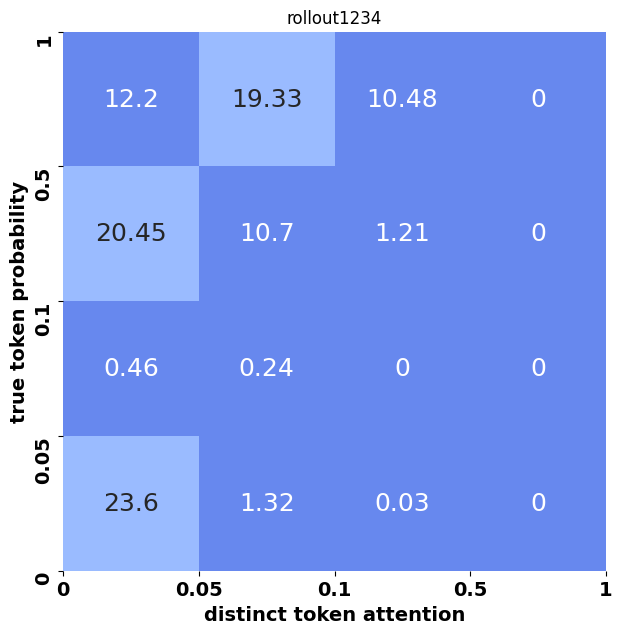

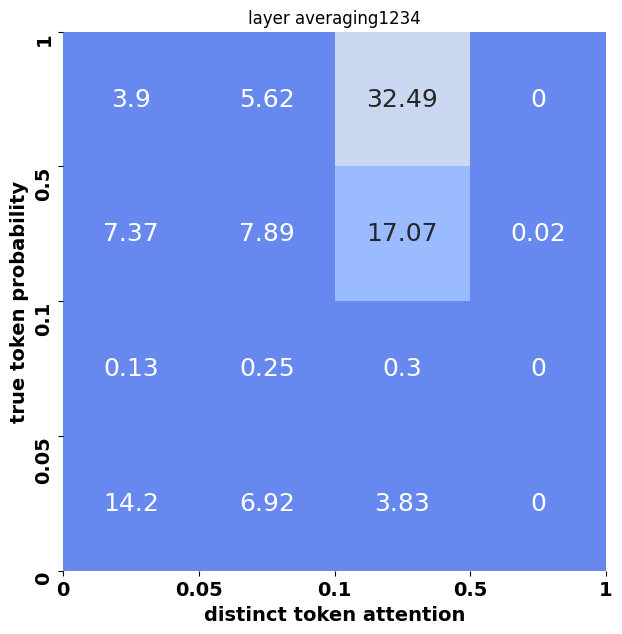

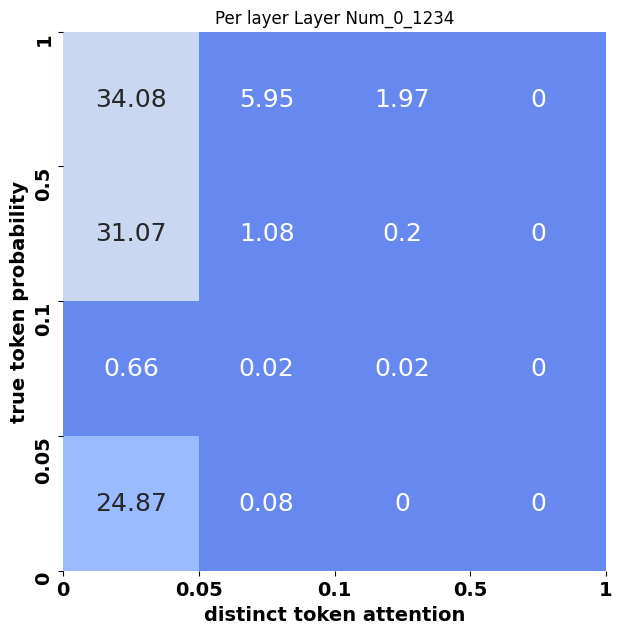

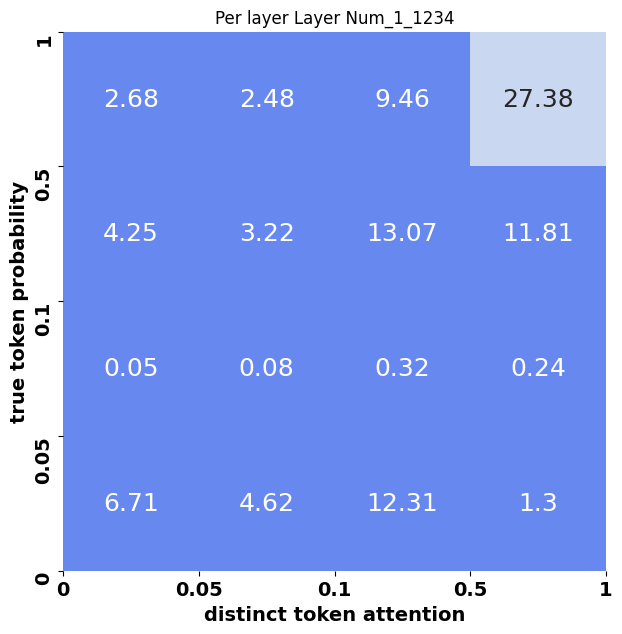

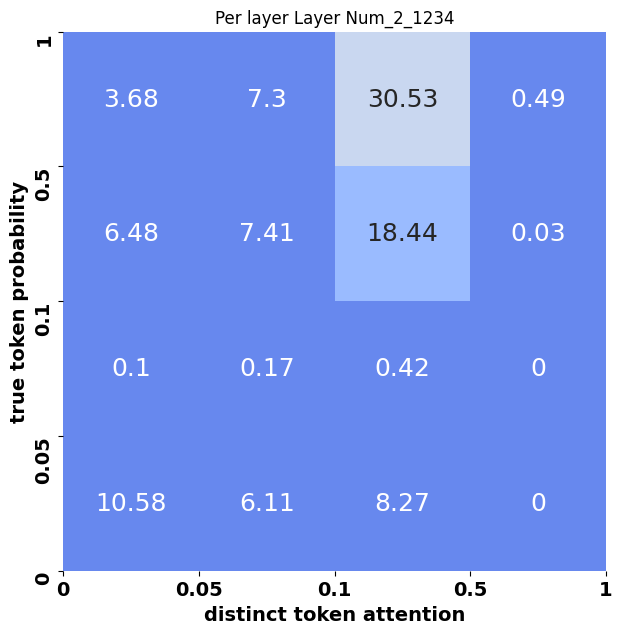

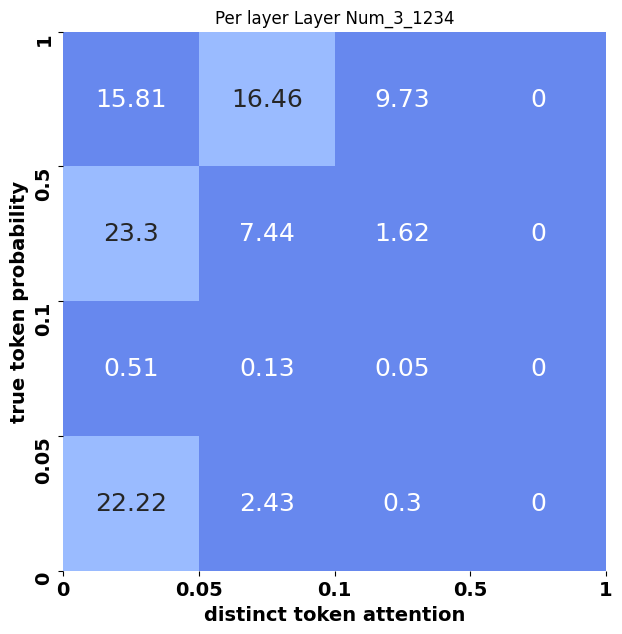

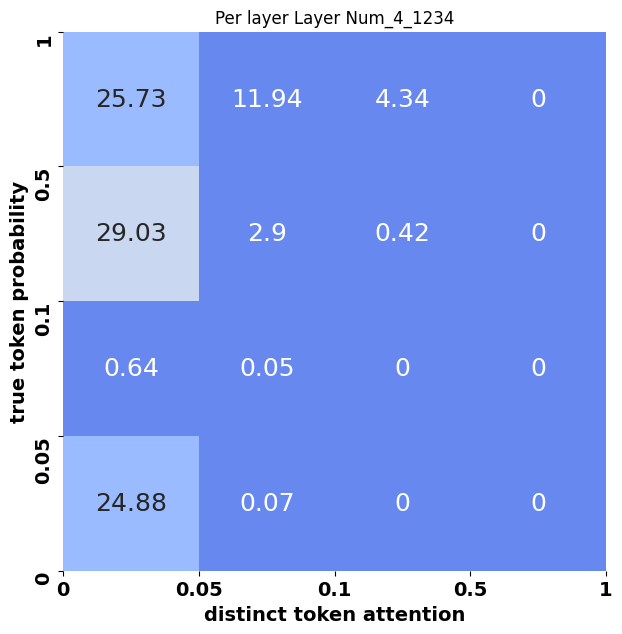

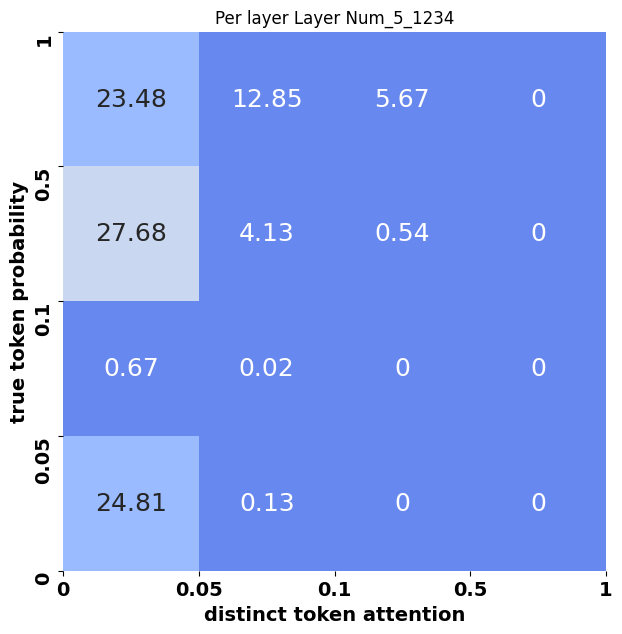

Initializing baseline model instance...1235
Initializing token embeddings with GloVe...
✓ Token embeddings initialized with GloVe
Baseline model loaded.


100%|██████████| 5928/5928 [18:47<00:00,  5.26it/s]


Baseline Validation Results...1235
Rollout:           0.0587
Layer-Avg:         0.1204
Max-Pooling:       0.5026
Comprehensiveness: 0.3795 (higher = better)
Sufficiency:       0.6889 (lower = better)


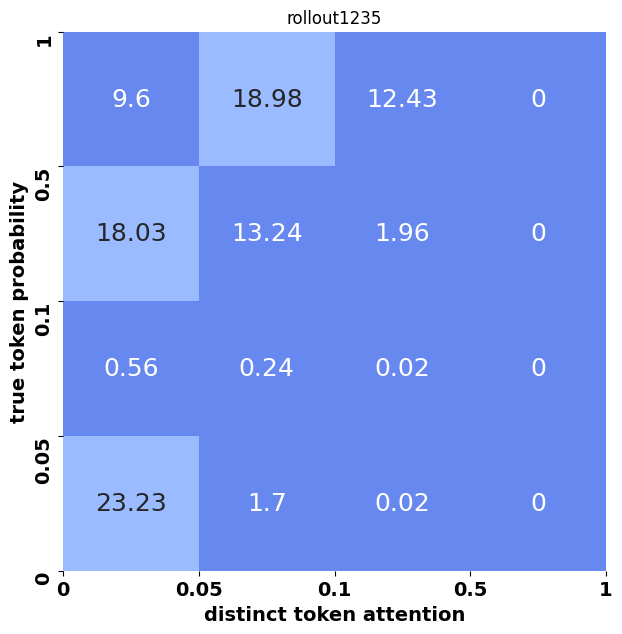

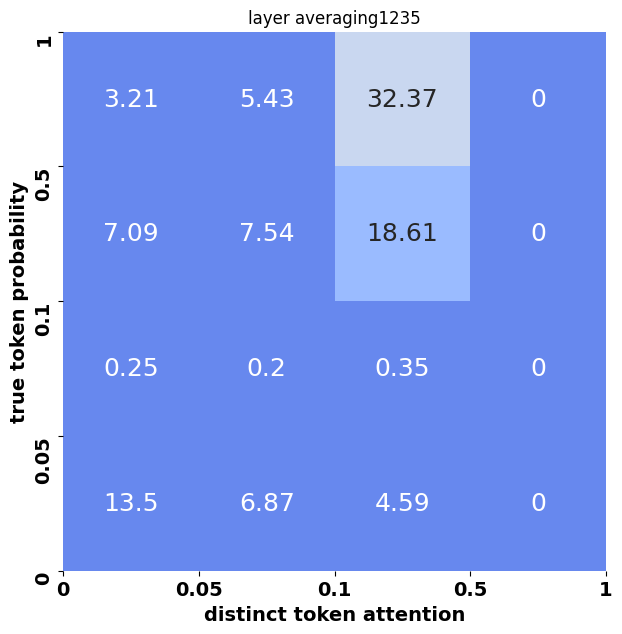

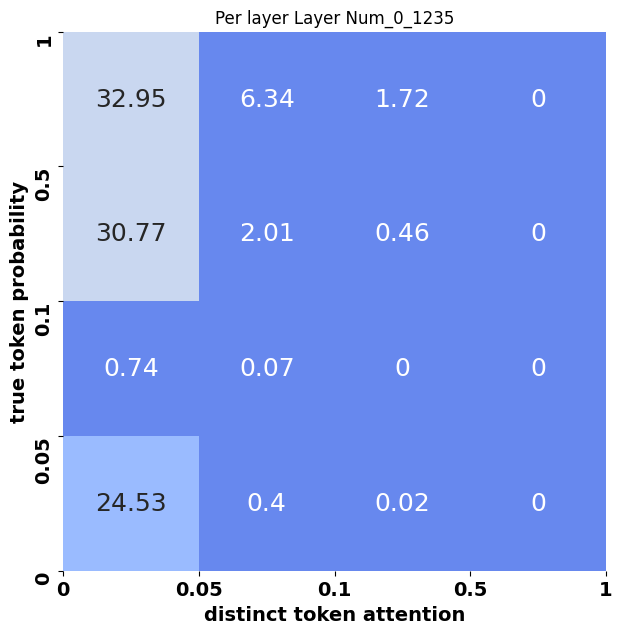

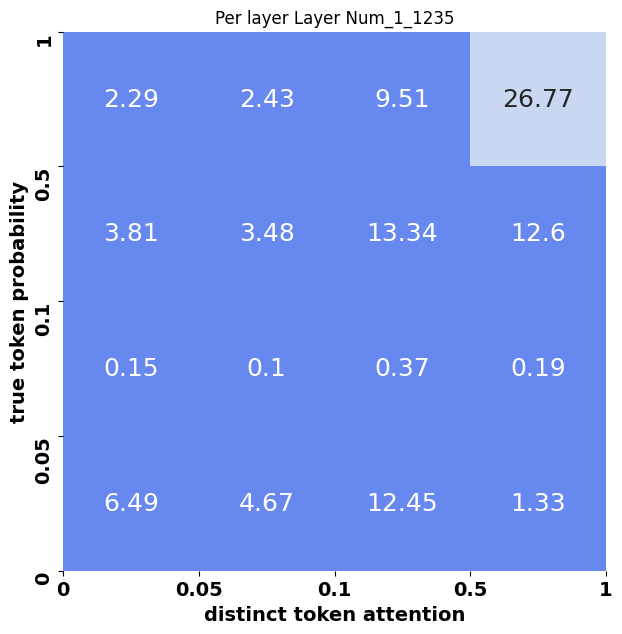

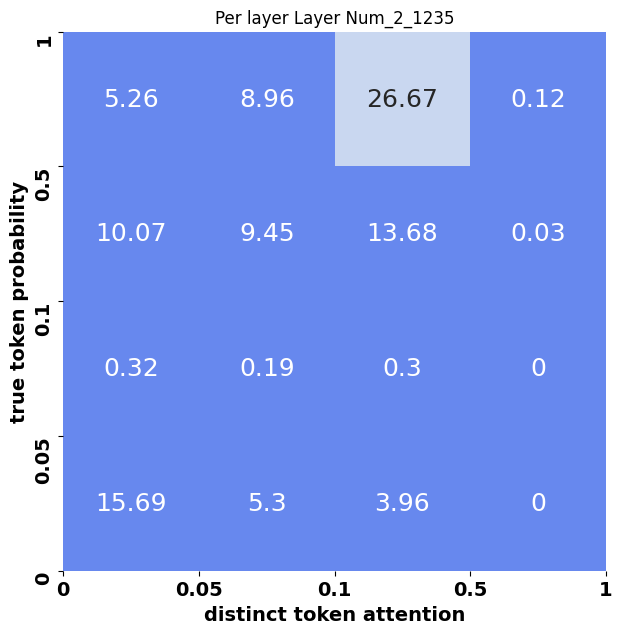

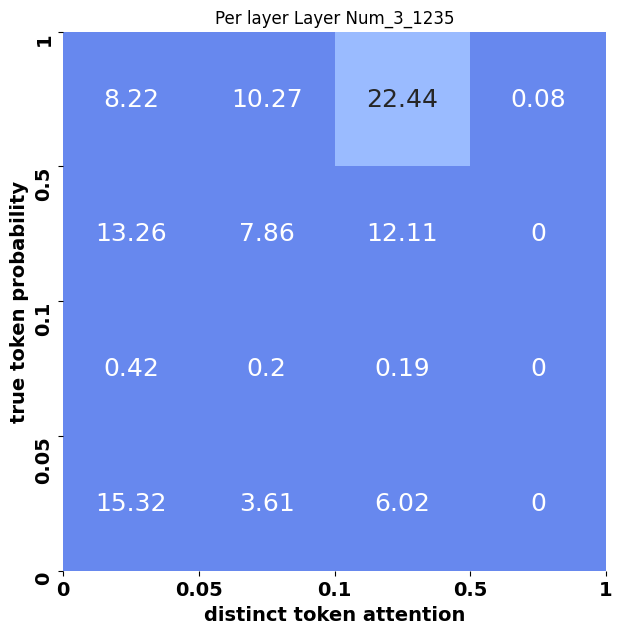

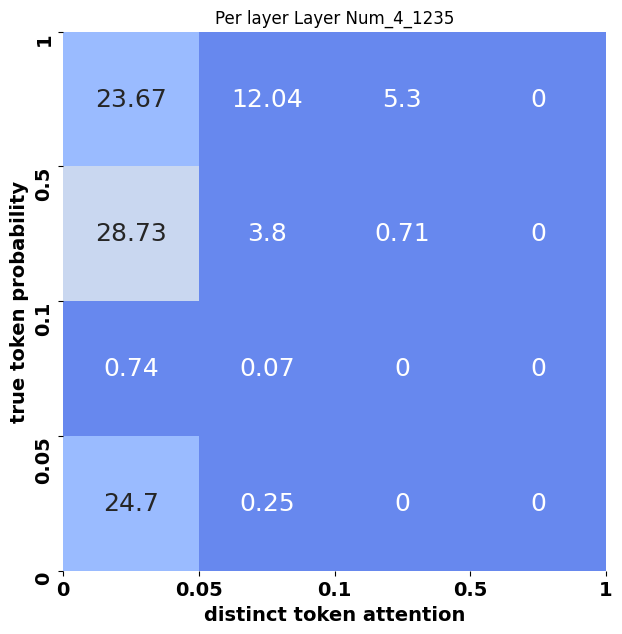

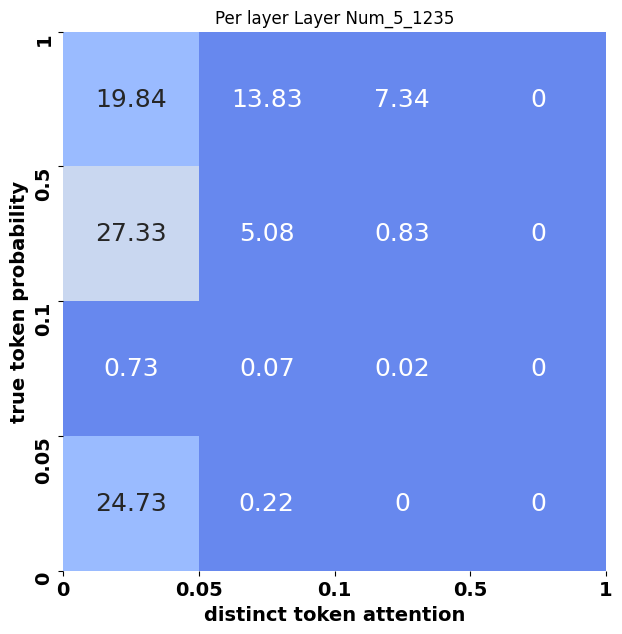

Initializing baseline model instance...1236
Initializing token embeddings with GloVe...
✓ Token embeddings initialized with GloVe
Baseline model loaded.


100%|██████████| 5928/5928 [20:05<00:00,  4.92it/s]

Baseline Validation Results...1236
Rollout:           0.0547
Layer-Avg:         0.1132
Max-Pooling:       0.4887
Comprehensiveness: 0.3454 (higher = better)
Sufficiency:       0.6762 (lower = better)


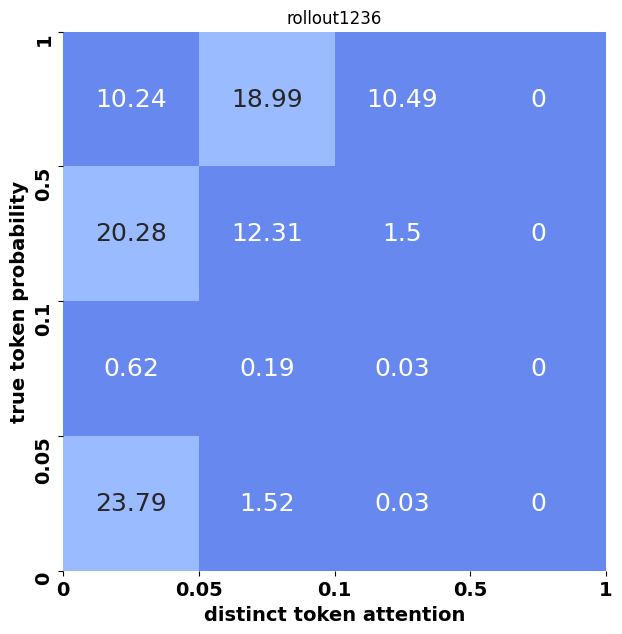

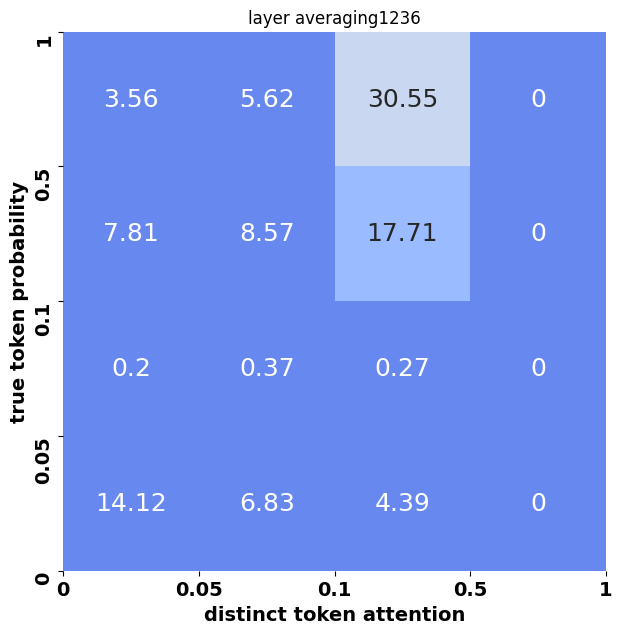

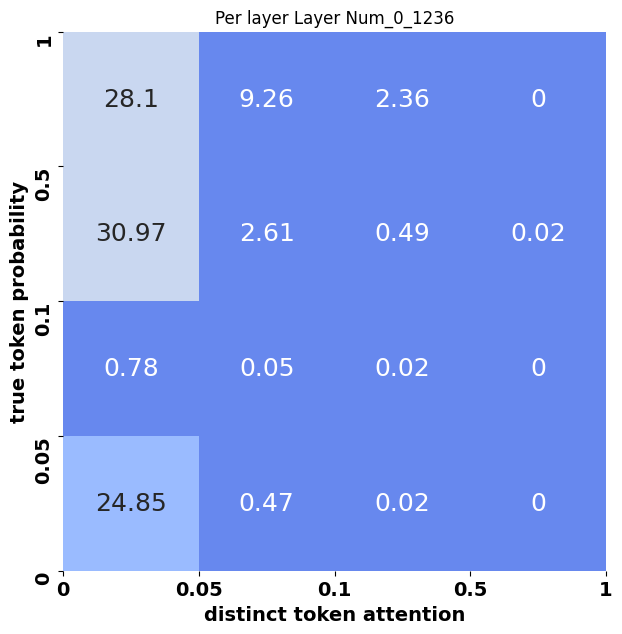

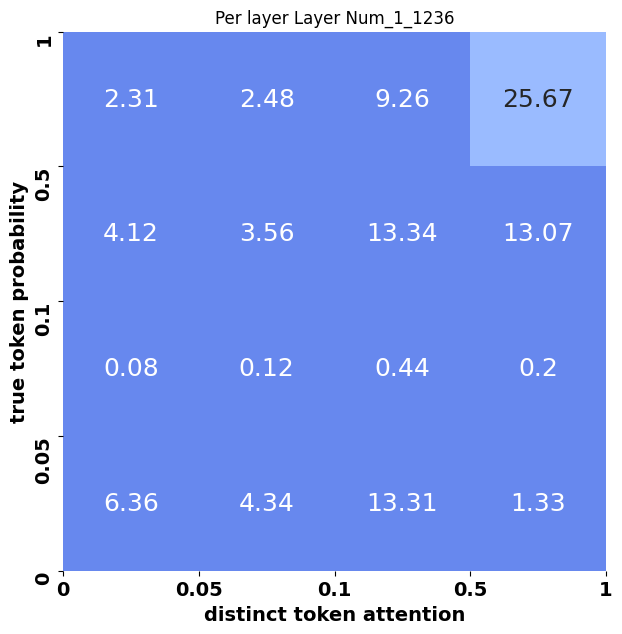

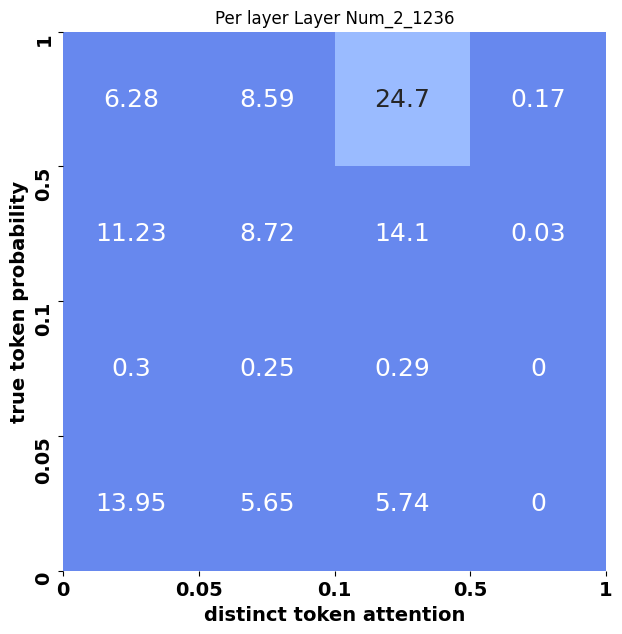

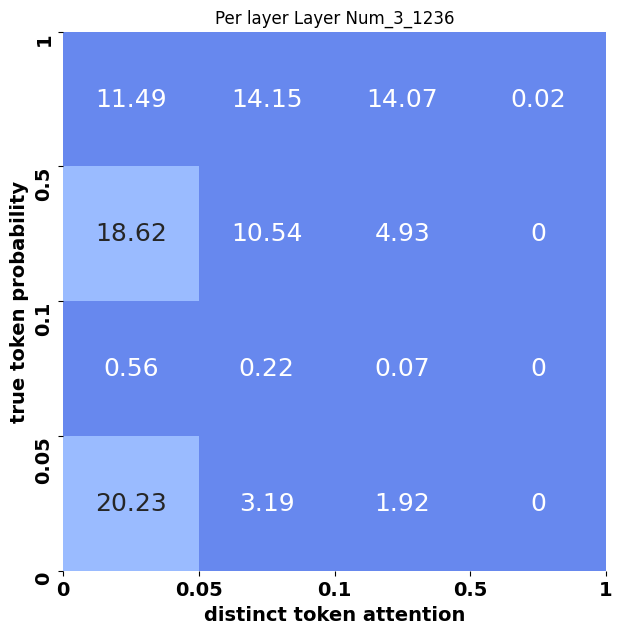

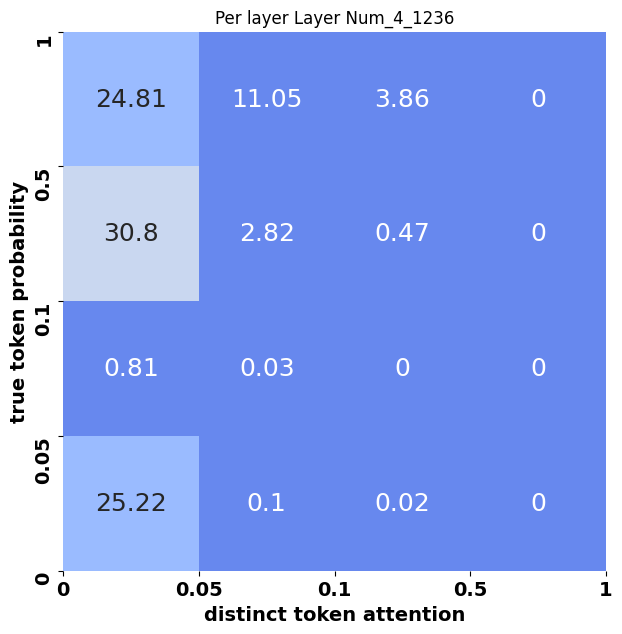

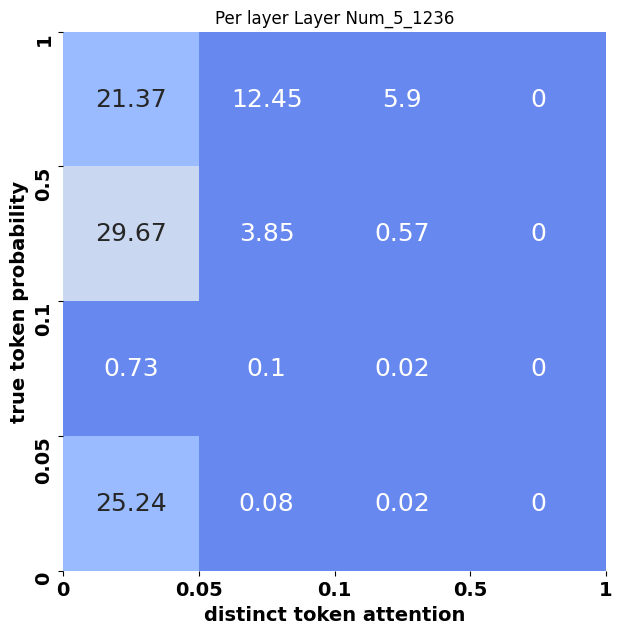

Initializing baseline model instance...1237
Initializing token embeddings with GloVe...
✓ Token embeddings initialized with GloVe
Baseline model loaded.


100%|██████████| 5928/5928 [20:11<00:00,  4.89it/s]


Baseline Validation Results...1237
Rollout:           0.0515
Layer-Avg:         0.1158
Max-Pooling:       0.4938
Comprehensiveness: 0.3621 (higher = better)
Sufficiency:       0.7036 (lower = better)


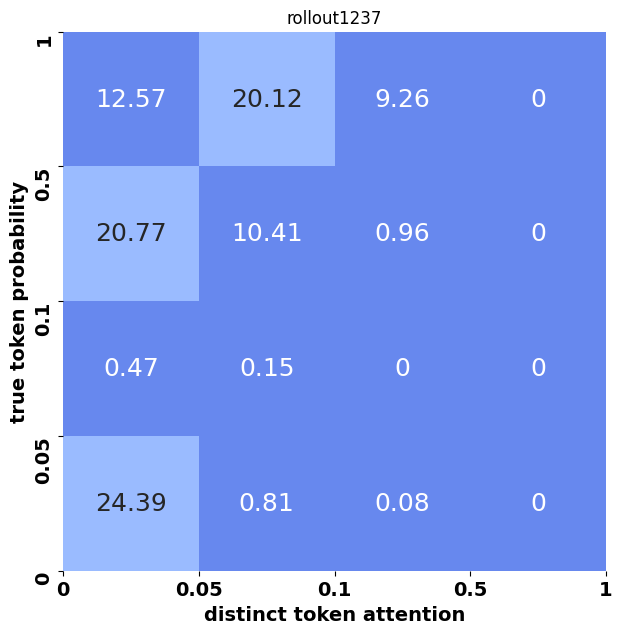

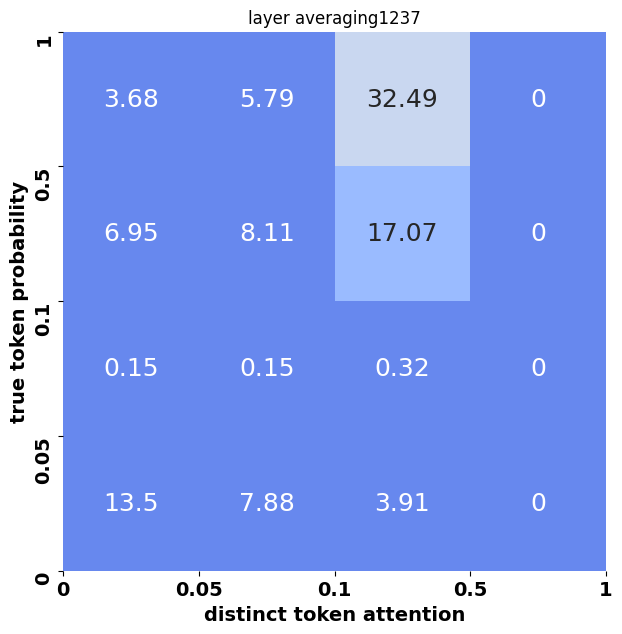

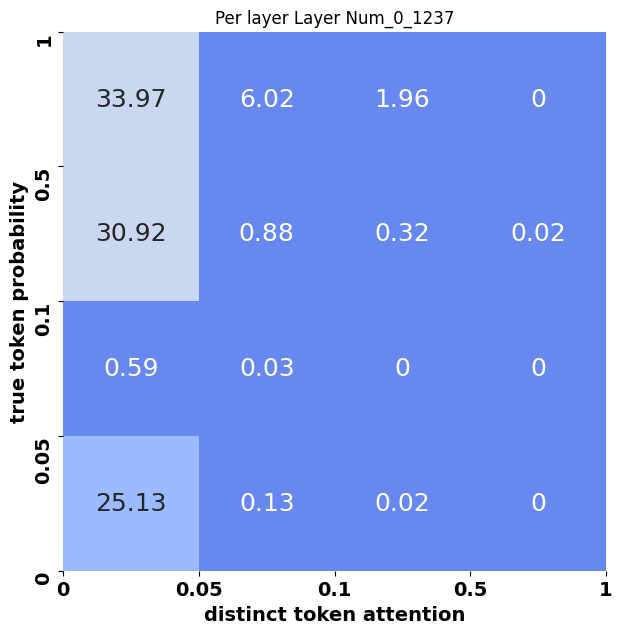

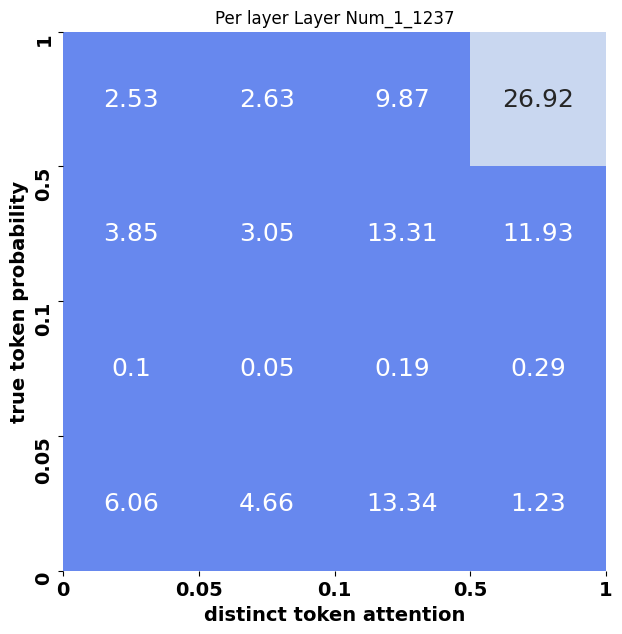

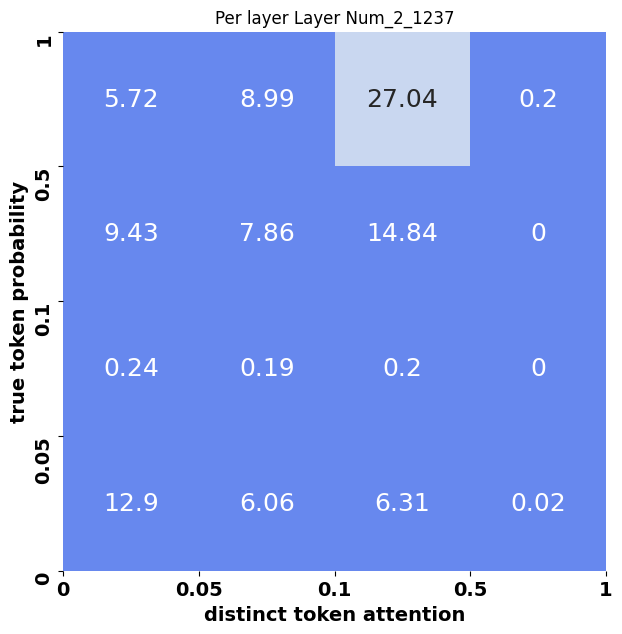

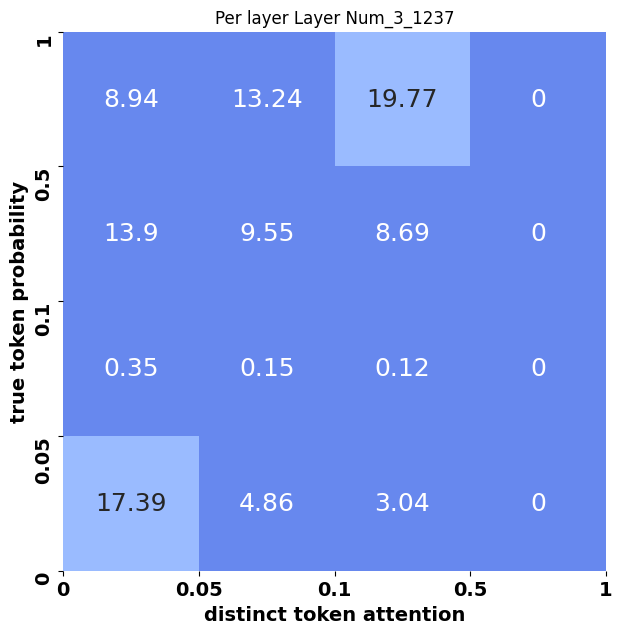

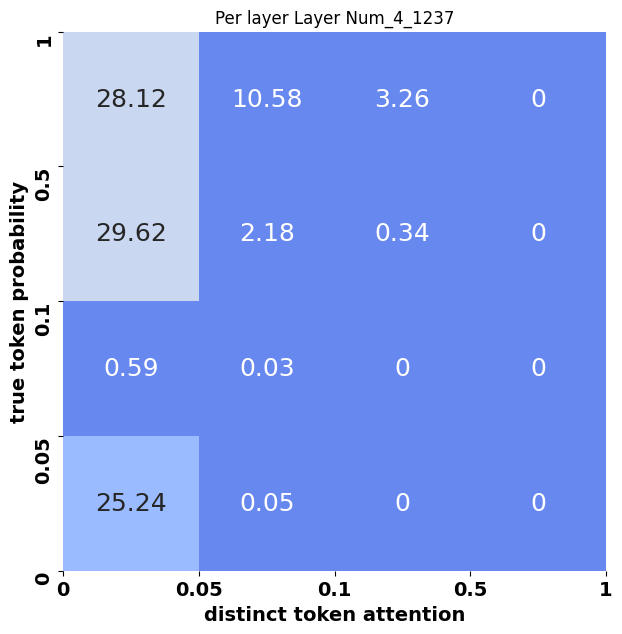

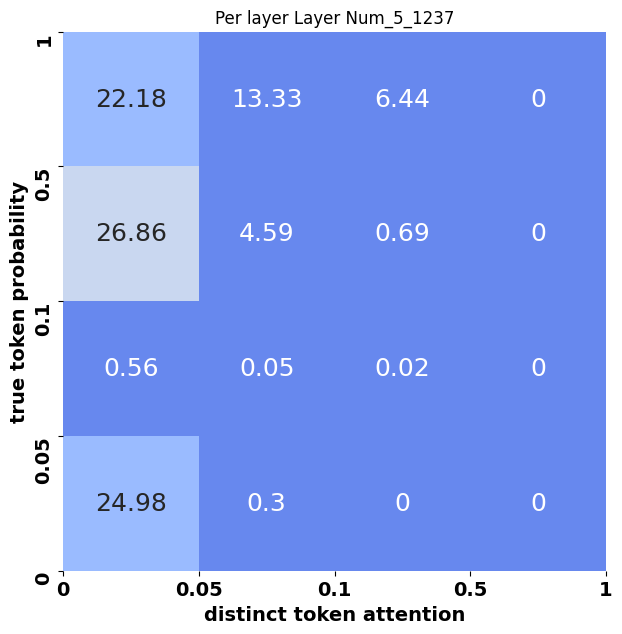

Initializing baseline model instance...1238
Initializing token embeddings with GloVe...
✓ Token embeddings initialized with GloVe
Baseline model loaded.


100%|██████████| 5928/5928 [17:12<00:00,  5.74it/s]


Baseline Validation Results...1238
Rollout:           0.0597
Layer-Avg:         0.1253
Max-Pooling:       0.5199
Comprehensiveness: 0.4141 (higher = better)
Sufficiency:       0.6957 (lower = better)


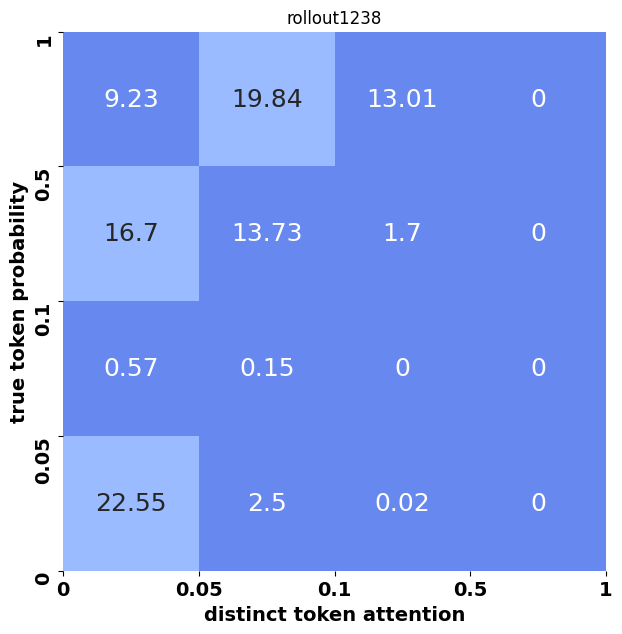

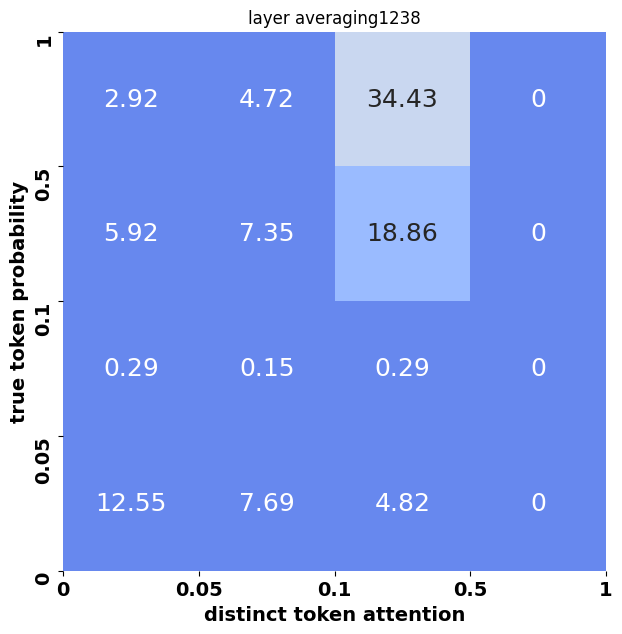

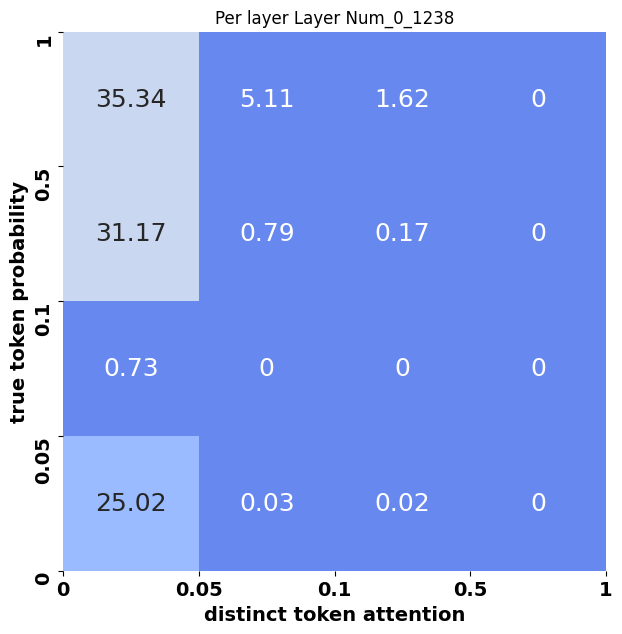

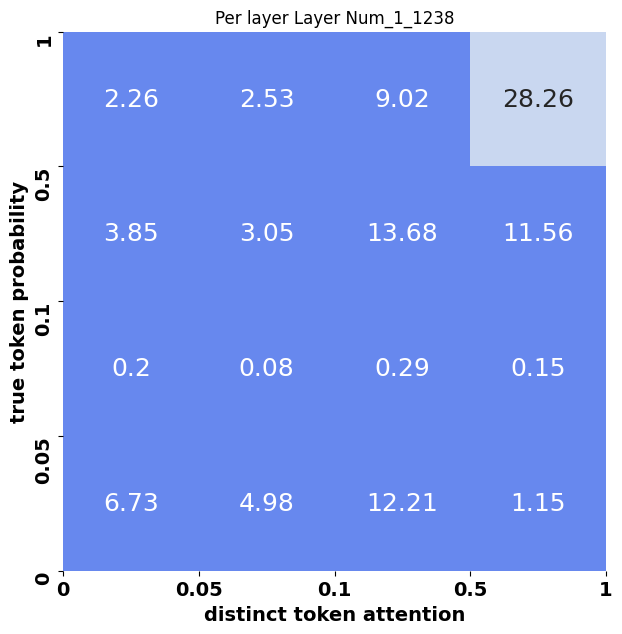

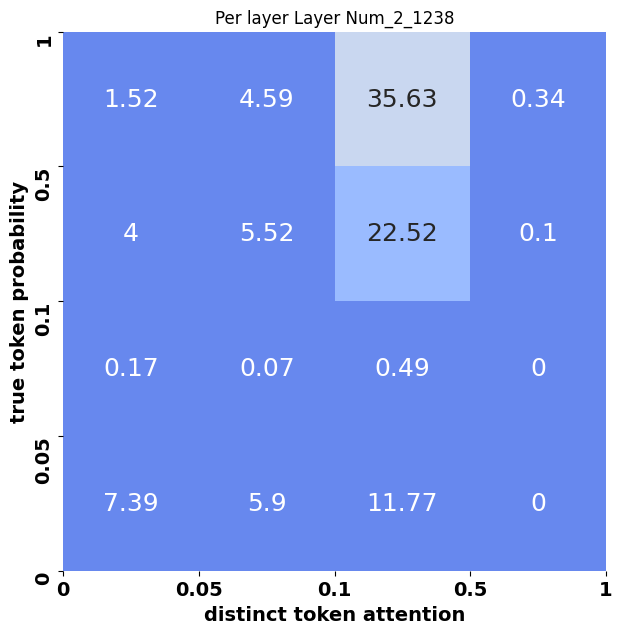

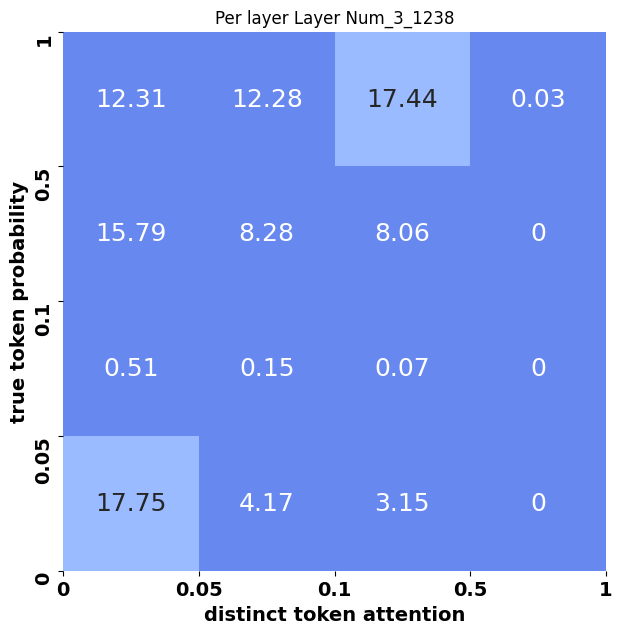

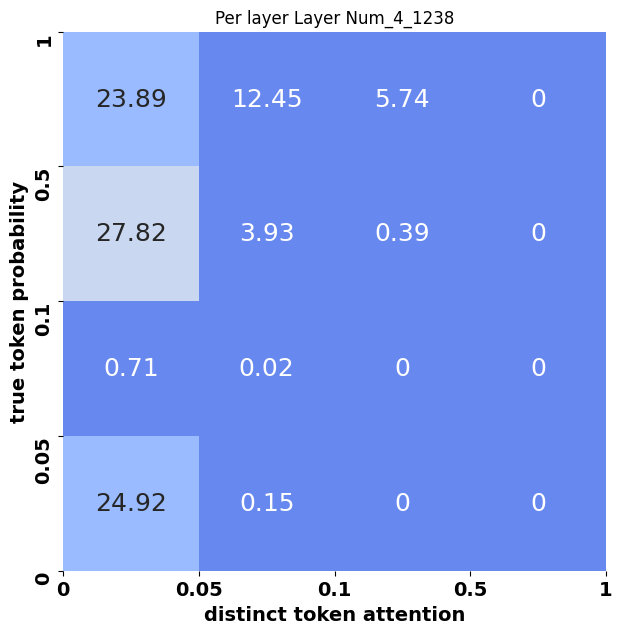

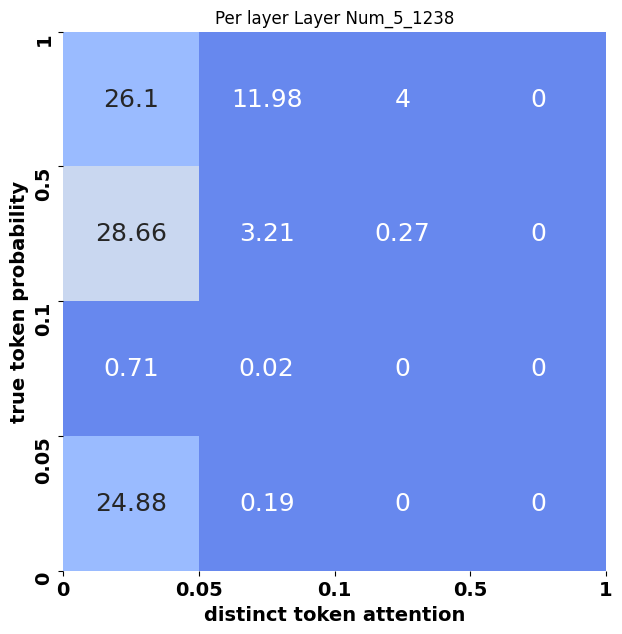

In [ ]:
seeds_list = [1234, 1235,1236, 1237, 1238]

DEV_JSON = "dev-v2.0.json" #"dev-v2.0.json"
print("Loading tokenizer...")
tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token
DROPOUT = 0.2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Loading dataset...")
val_dataset = load_squad_with_spans(DEV_JSON)
print(f"Loaded {len(val_dataset)} examples (focus spans included)")
glove_file = download_and_extract_glove()
pretrained_embeddings = load_glove_embeddings(glove_file, tokenizer, D_MODEL)



for nseed in seeds_list:
    BASELINE_CKPT = """/content/best_baseline_"""+str(nseed)+""".pt""" #"best_qk.pt"  #"best_baseline.pt"  #  "best_qk.pt"
    model_kwargs = dict(vocab_size=tokenizer.vocab_size,
                        d_model=D_MODEL, n_heads=N_HEADS,
                        n_layers=N_LAYERS, d_ff=D_FF,
                        max_seq_len=MAX_SEQ_LEN,
                        dropout=DROPOUT,pretrained_embeddings=pretrained_embeddings)
    print("Initializing baseline model instance..."+str(nseed))
    baseline = GPTAnswerGenerator(**model_kwargs).to(device)
    baseline_ckpt = torch.load(BASELINE_CKPT, map_location=device)
    baseline.load_state_dict(baseline_ckpt["model"])
    print("Baseline model loaded.")



    # Usage in your main loop:
    n_samples = 6000
    items = val_dataset.data[:n_samples]

    Attn_Scores_Rollout = []
    Attn_Scores_LayerAvg = []
    Attn_Scores_MaxPool = []
    Comprehensiveness_Scores = []
    Sufficiency_Scores = []

    Prediction_Scores = []
    # Per-layer attention scores: list of length N_LAYERS, each is a list over datapoints
    Attn_Scores_PerLayer = [[] for _ in range(N_LAYERS)]

    for item in tqdm(items):
        question = item["question"]
        context = item["context"]
        gold = item["answer"]
        answer_positions, ids = get_answer_token_positions(
            question, context, item["answer_start"], item["answer_end"], tokenizer
        )
        pred, attn_steps, prob_steps = generate_faithful(baseline, tokenizer, context, question, device)

        if not attn_steps:
            continue

        # Compute attention mass metrics
        rollout_mass, layer_avg_mass, max_pool_mass, rollout_attn_probs, per_layer_means = attention_mass(
            attn_steps, answer_positions, alpha=0.5
        )

        # Prediction score for the *correct* output (same for all attention methods)
        pred_score = compute_prediction_score(baseline, tokenizer, context, question, gold, device)
        Prediction_Scores.append(pred_score)

        # Store per-layer attention masses (one value per layer for this datapoint)
        for li, mval in enumerate(per_layer_means):
            if li < len(Attn_Scores_PerLayer):
                Attn_Scores_PerLayer[li].append(mval)

        # Compute comprehensiveness and sufficiency
        comp, suff = compute_comprehensiveness_sufficiency(
            baseline, tokenizer, context, question, device,
            attn_steps, prob_steps, ids, rollout_attn_probs, k_percent=5
        )

        Attn_Scores_Rollout.append(rollout_mass)
        Attn_Scores_LayerAvg.append(layer_avg_mass)
        Attn_Scores_MaxPool.append(max_pool_mass)
        Comprehensiveness_Scores.append(comp)
        Sufficiency_Scores.append(suff)

    # Print results
    print("Baseline Validation Results..."+str(nseed))
    print(f"Rollout:           {np.mean(Attn_Scores_Rollout):.4f}")
    print(f"Layer-Avg:         {np.mean(Attn_Scores_LayerAvg):.4f}")
    print(f"Max-Pooling:       {np.mean(Attn_Scores_MaxPool):.4f}")
    print(f"Comprehensiveness: {np.mean(Comprehensiveness_Scores):.4f} (higher = better)")
    print(f"Sufficiency:       {np.mean(Sufficiency_Scores):.4f} (lower = better)")


    plot_heatmap(Attn_Scores_Rollout,Prediction_Scores,
                 name="rollout"+str(nseed))
    plot_heatmap(Attn_Scores_LayerAvg,Prediction_Scores,
                 name="layer averaging"+str(nseed))

    for l in range(len(Attn_Scores_PerLayer)):
      plot_heatmap(Attn_Scores_PerLayer[l],Prediction_Scores,
                   name="Per layer Layer Num_" +str(l)+"_"+str(nseed))





In [ ]:
len(Attn_Scores_PerLayer[5]),len(Prediction_Scores)

(5928, 5928)

In [ ]:
# print("attention",sum( np.array(Attn_Scores_Rollout)<=0.05)/len(Attn_Scores_Rollout),sum(np.logical_and(np.array(Attn_Scores_Rollout)>0.05, np.array(Attn_Scores_Rollout)<=0.1))/len(Attn_Scores_Rollout),sum(np.array(Attn_Scores_Rollout)>0.1)/len(Attn_Scores_Rollout))
# print("prediction",sum( np.array(Prediction_Scores)<=0.05)/len(Prediction_Scores),sum(np.logical_and(np.array(Prediction_Scores)>0.05, np.array(Prediction_Scores)<=0.1))/len(Prediction_Scores),sum(np.array(Prediction_Scores)>0.1)/len(Prediction_Scores))
# fig, ax = plt.subplots()
# h, xedges, yedges, im = ax.hist2d(np.array(Attn_Scores_Rollout),
#                                   np.array(Prediction_Scores),[[0,0.05,0.1,0.5,1.001],[0,0.05,0.1,0.5,1.001]])
# plt.close(fig)
# temp = (h.T/h.sum())*100

# # Prevent automatic plotting by removing `plt.show()`
# # or manually remove the image
# im.remove()  # This prevents the heatmap from being displayed
# plt.figure(figsize=(7,7))
# ax = sns.heatmap(np.round(temp,2),vmin=5,vmax=70,annot=np.round(temp,2),fmt="g",cmap=sns.color_palette("coolwarm"),
# yticklabels=[0.05,0.1,0.5,1.],
# xticklabels=[0.05,0.1,0.5,1.],annot_kws={"size":18},cbar=False)
# ax.invert_yaxis()
# plt.xlabel(r"distinct token attention",fontweight="bold",fontsize=14)
# plt.ylabel(r"true token probability",fontweight="bold",fontsize=14) # change xlabel based on algo
# plt.xticks([0,1,2,3,4],[0,0.05,0.1,0.5,1],weight="bold",fontsize=14)
# plt.yticks([0,1,2,3,4],[0,0.05,0.1,0.5,1],weight="bold", va="top",fontsize=14)
# #plt.savefig("./"+name+".pdf",bbox_inches='tight')

Loading tokenizer...
Loading dataset...
Loaded 5928 examples (focus spans included)
✓ GloVe embeddings found: glove.6B.300d.txt

LOADING GLOVE EMBEDDINGS
Reading GloVe file (this takes ~1 minute)...


Loading GloVe: 400001it [00:28, 14204.11it/s]                            


✓ Loaded 400,001 GloVe vectors
Matching tokenizer vocabulary with GloVe...


Matching: 100%|██████████| 50257/50257 [00:00<00:00, 387454.62it/s]

✓ Matched 43,058/50,257 tokens (85.7%)

Initializing baseline model instance...1234


Initializing token embeddings with GloVe...
✓ Token embeddings initialized with GloVe
Baseline model loaded.


100%|██████████| 5928/5928 [18:57<00:00,  5.21it/s]


Baseline Validation Results...1234
Rollout:           0.1003
Layer-Avg:         0.1947
Max-Pooling:       0.6132
Comprehensiveness: 0.5466 (higher = better)
Sufficiency:       0.6075 (lower = better)


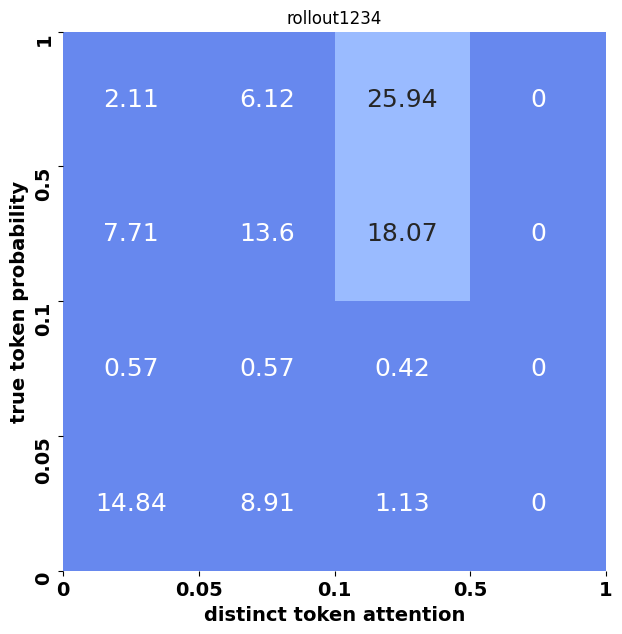

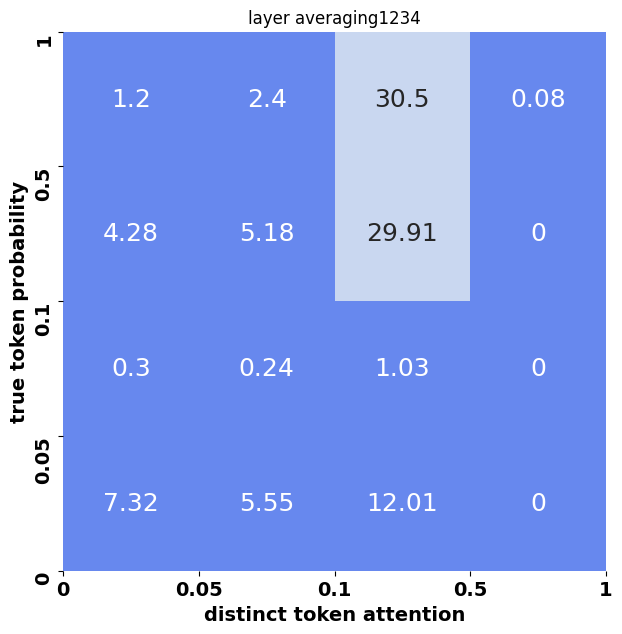

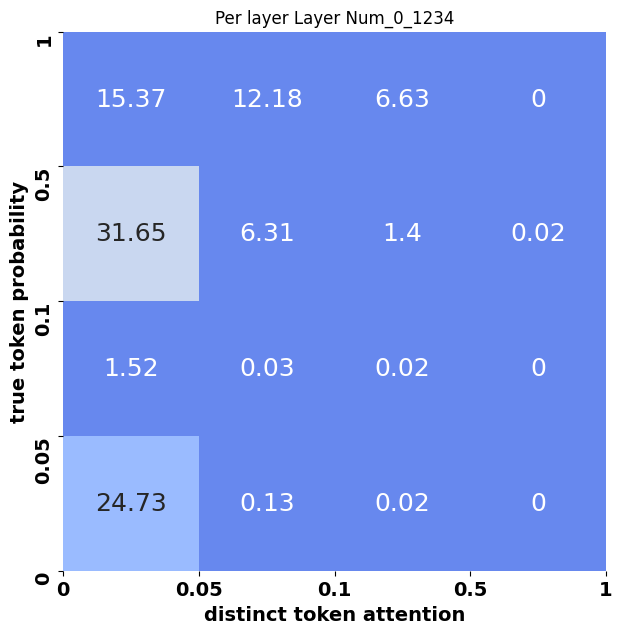

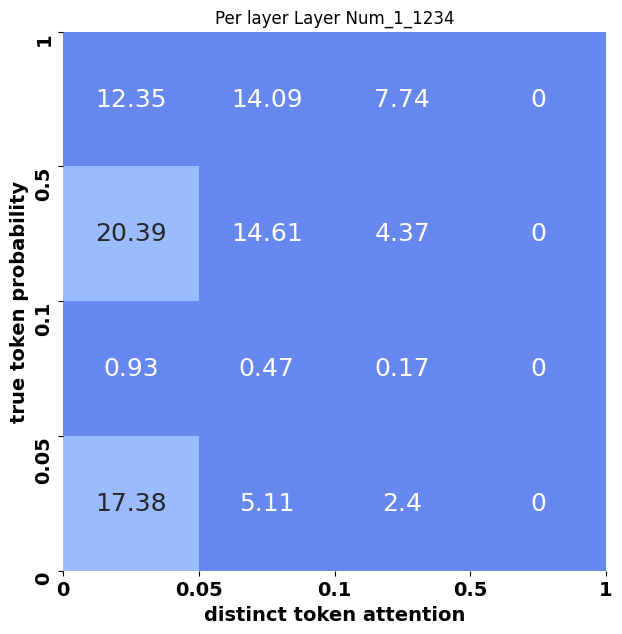

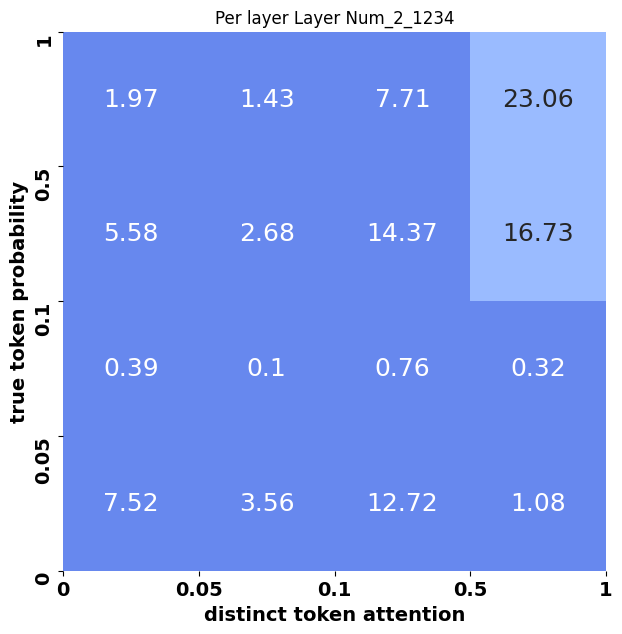

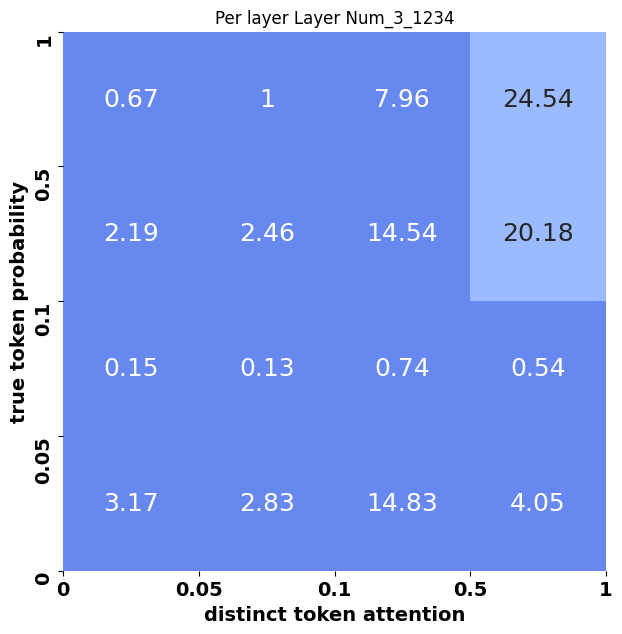

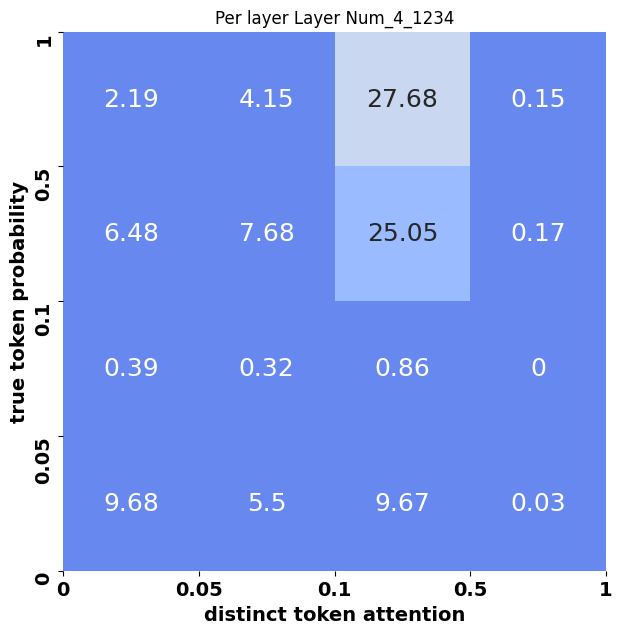

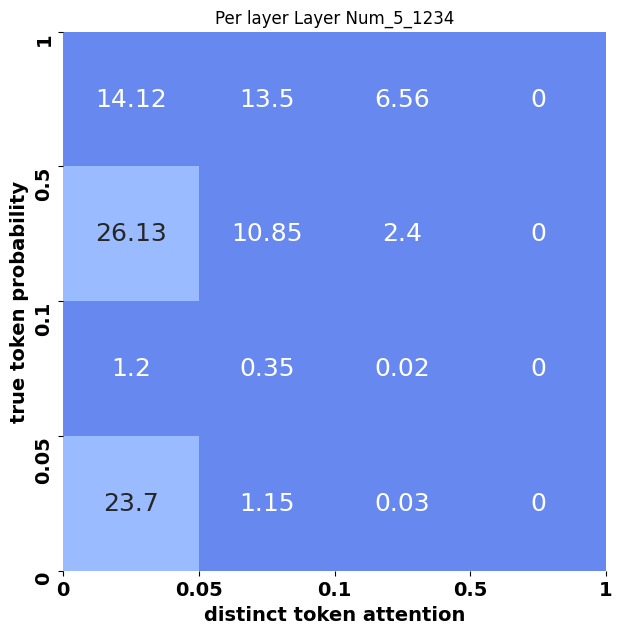

Initializing baseline model instance...1235
Initializing token embeddings with GloVe...
✓ Token embeddings initialized with GloVe
Baseline model loaded.


100%|██████████| 5928/5928 [20:50<00:00,  4.74it/s]

Baseline Validation Results...1235
Rollout:           0.0975
Layer-Avg:         0.1994
Max-Pooling:       0.6047
Comprehensiveness: 0.5390 (higher = better)
Sufficiency:       0.5488 (lower = better)


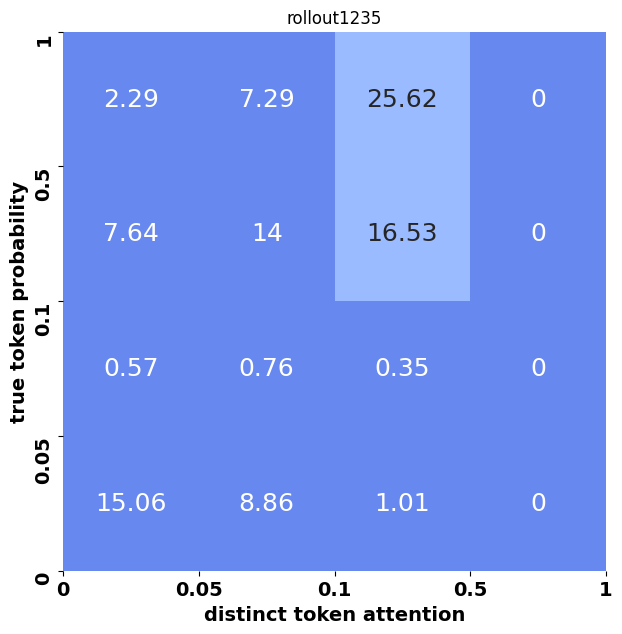

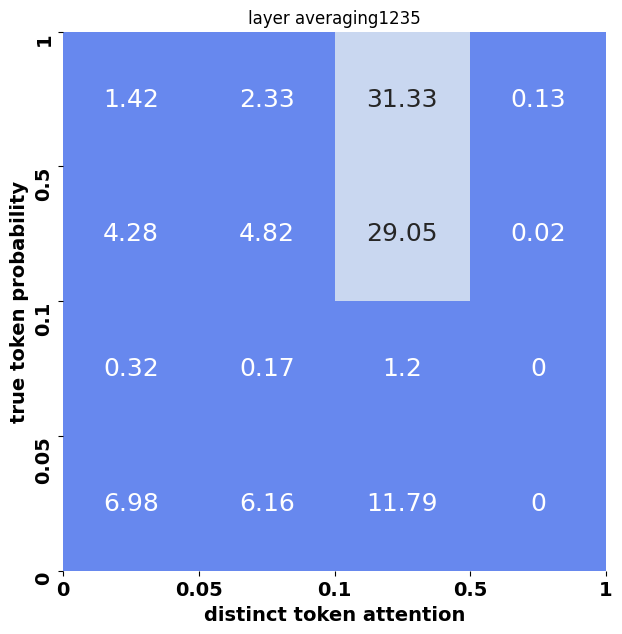

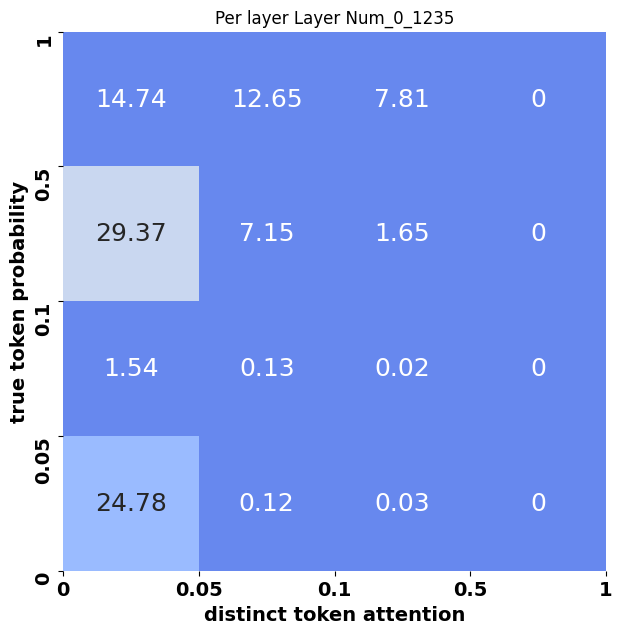

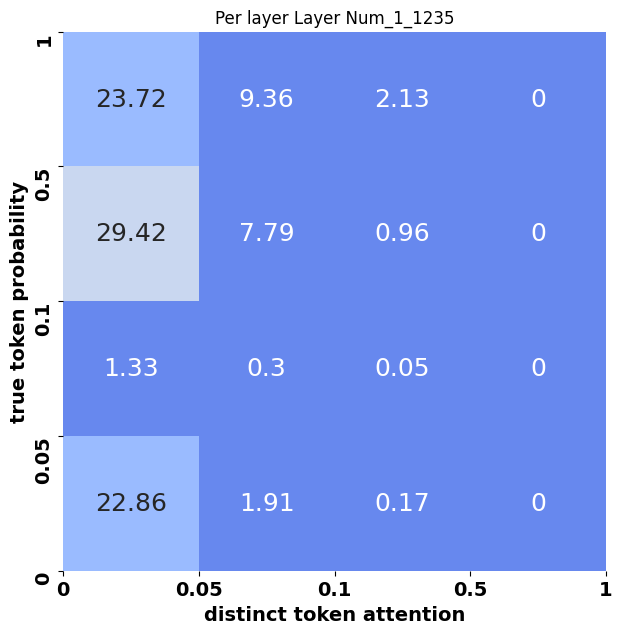

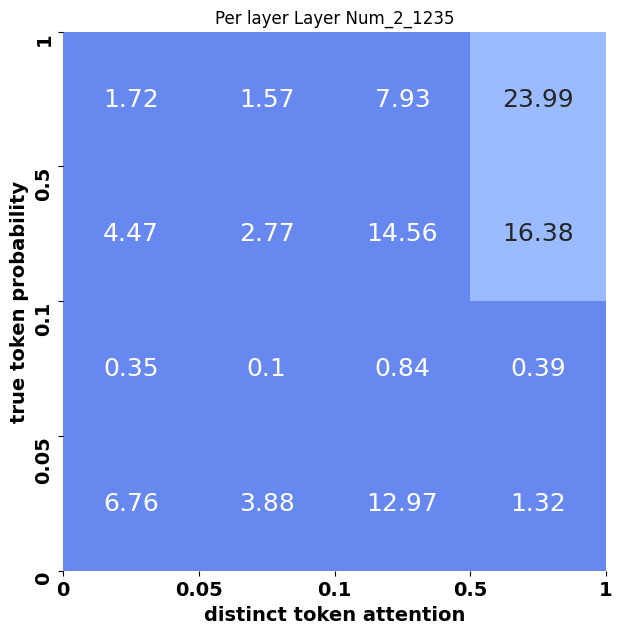

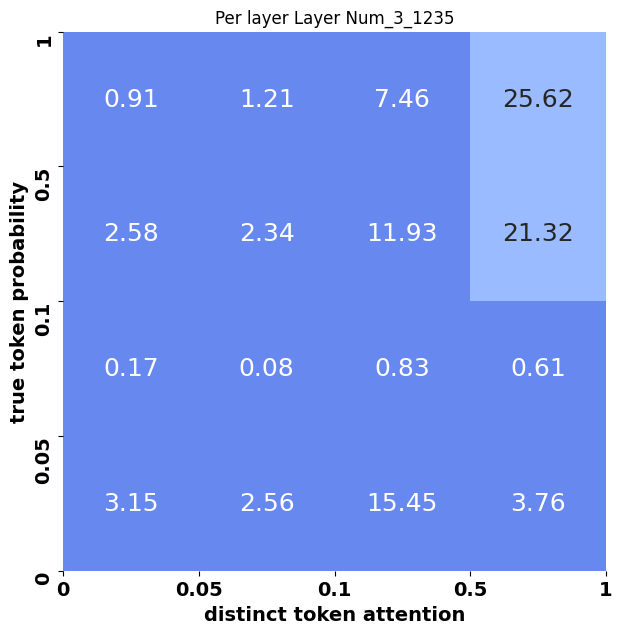

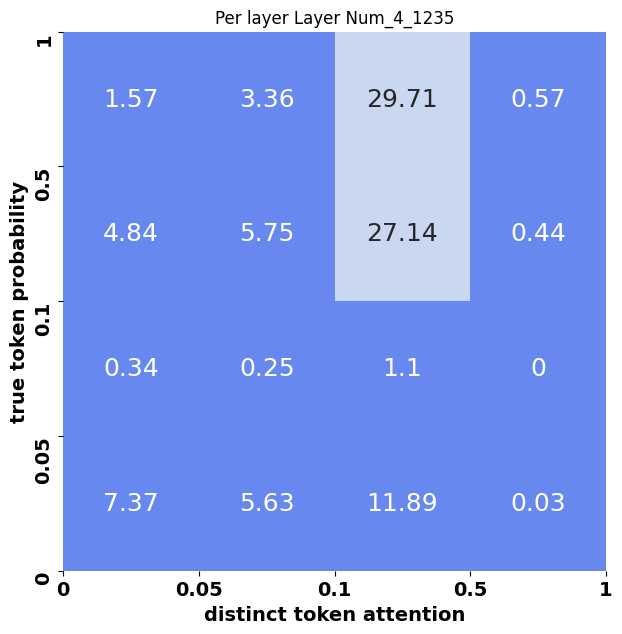

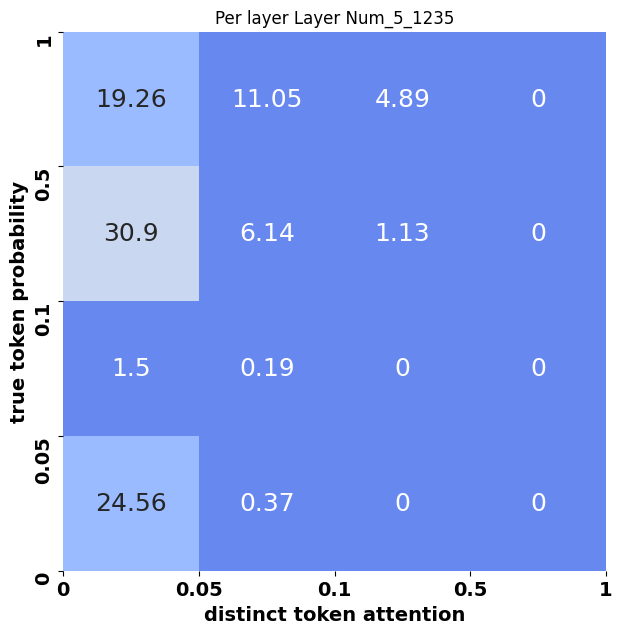

Initializing baseline model instance...1236
Initializing token embeddings with GloVe...
✓ Token embeddings initialized with GloVe
Baseline model loaded.


100%|██████████| 5928/5928 [17:56<00:00,  5.51it/s]


Baseline Validation Results...1236
Rollout:           0.0988
Layer-Avg:         0.2009
Max-Pooling:       0.6621
Comprehensiveness: 0.5294 (higher = better)
Sufficiency:       0.5591 (lower = better)


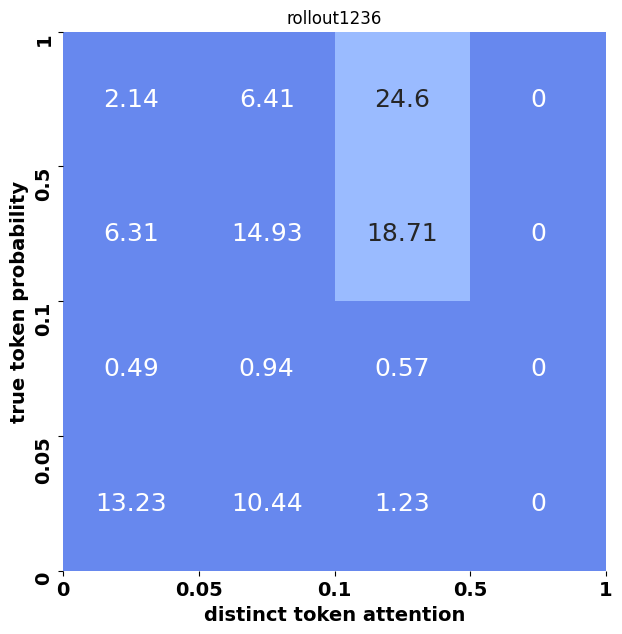

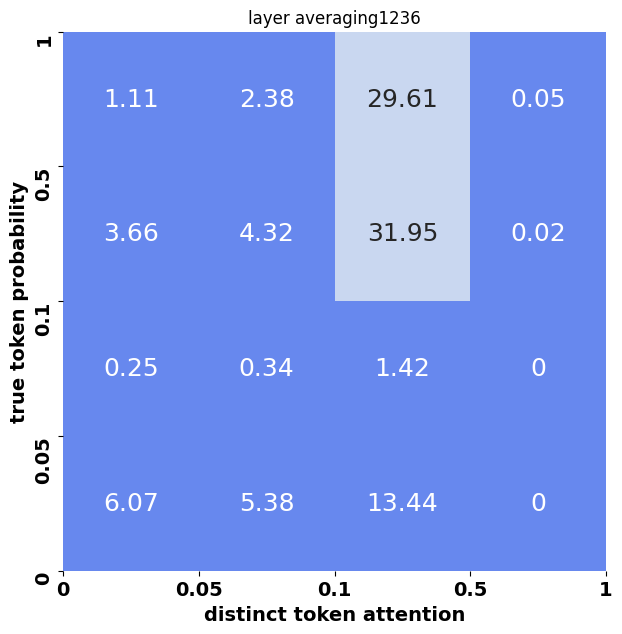

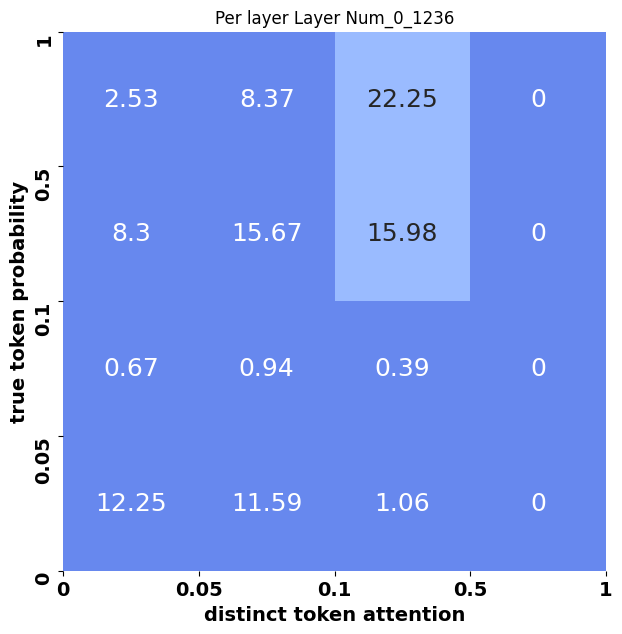

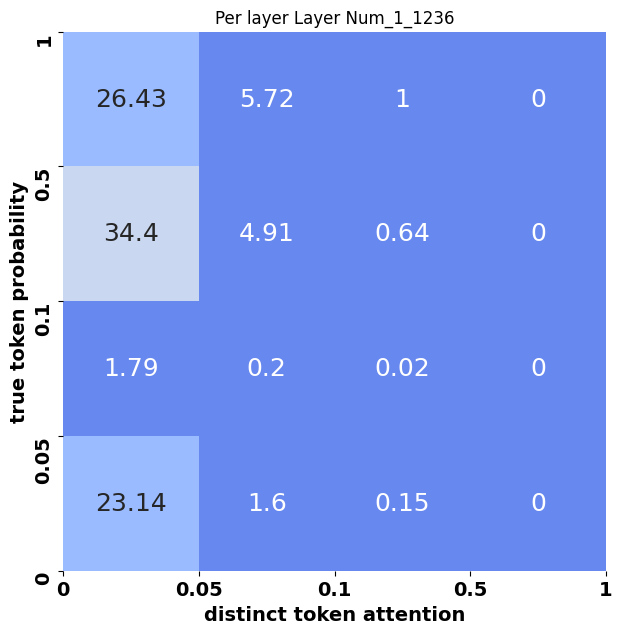

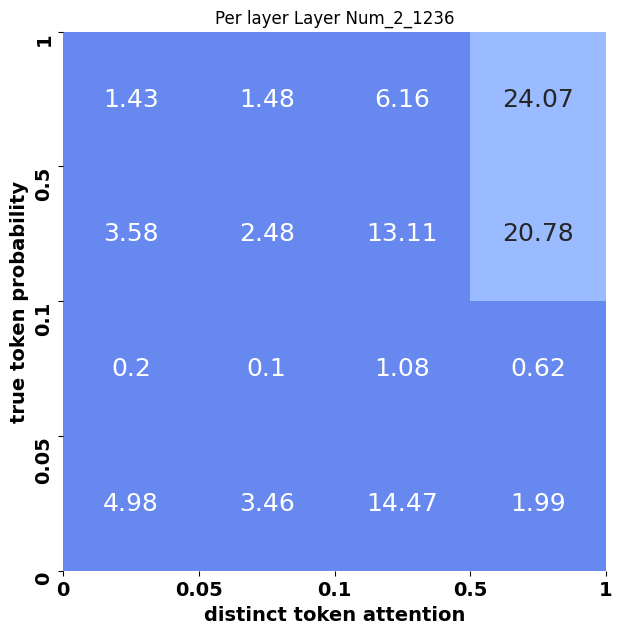

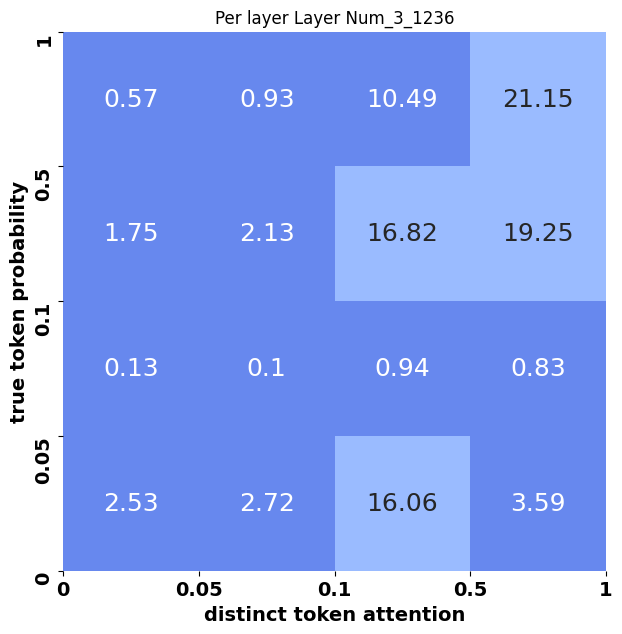

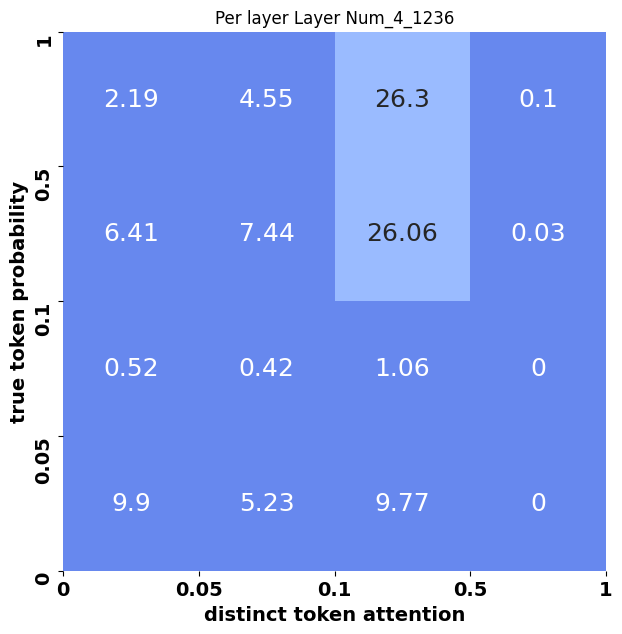

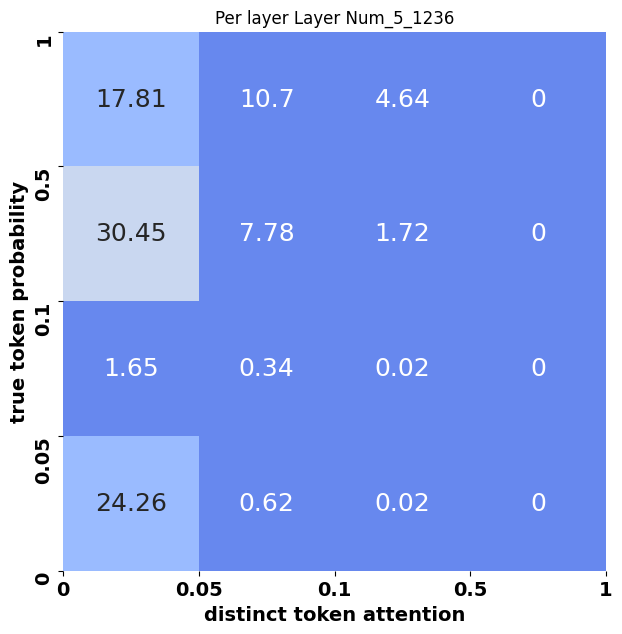

Initializing baseline model instance...1237
Initializing token embeddings with GloVe...
✓ Token embeddings initialized with GloVe
Baseline model loaded.


100%|██████████| 5928/5928 [17:26<00:00,  5.66it/s]


Baseline Validation Results...1237
Rollout:           0.0842
Layer-Avg:         0.1802
Max-Pooling:       0.5733
Comprehensiveness: 0.4878 (higher = better)
Sufficiency:       0.6867 (lower = better)


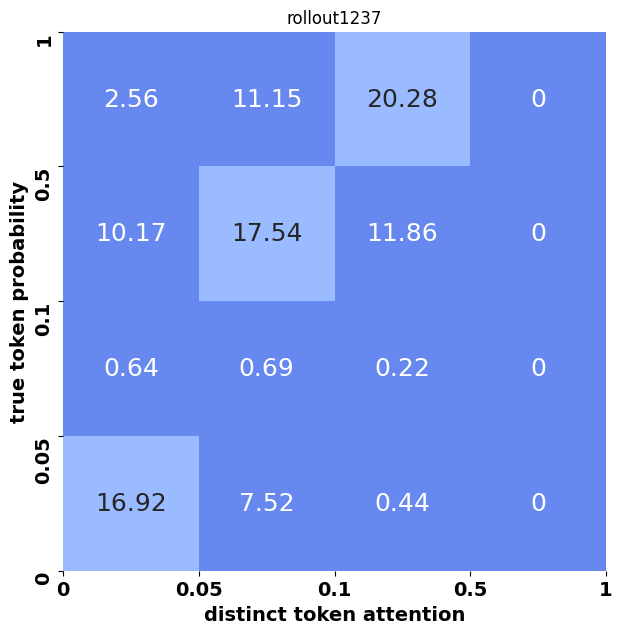

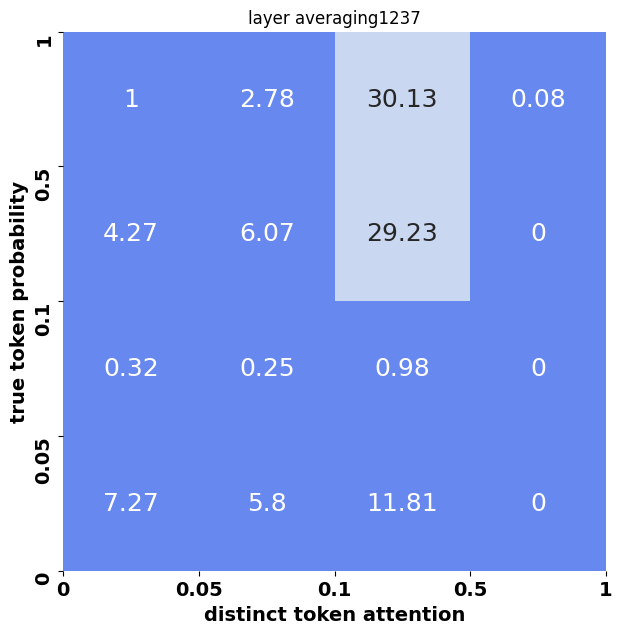

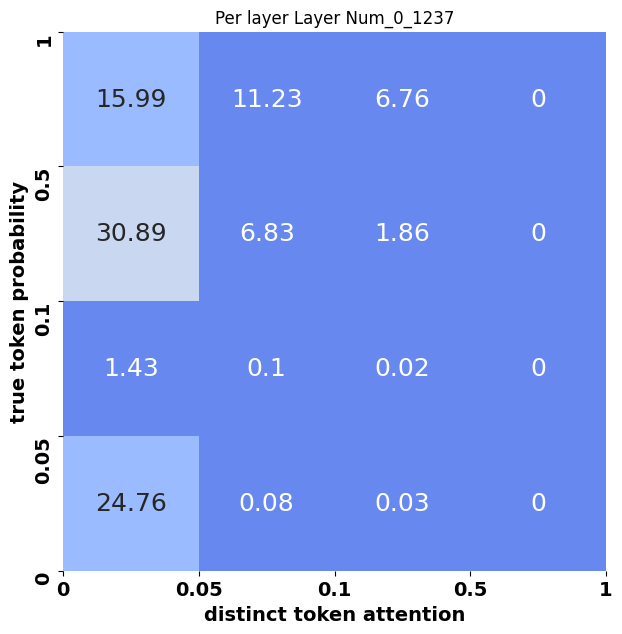

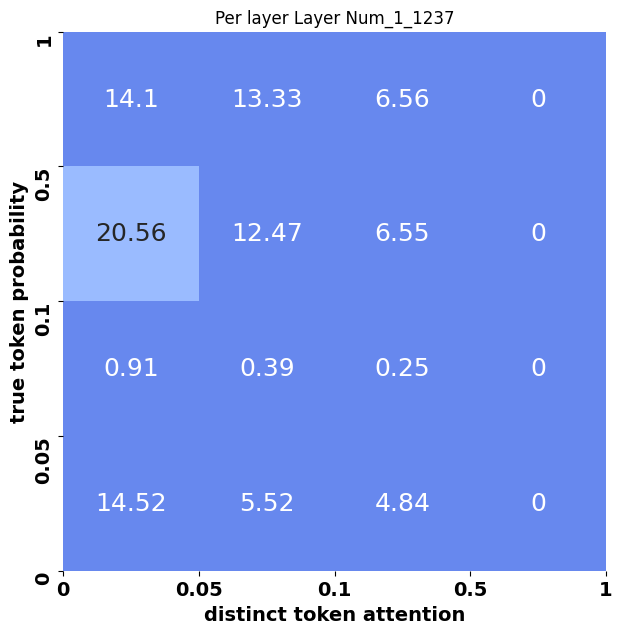

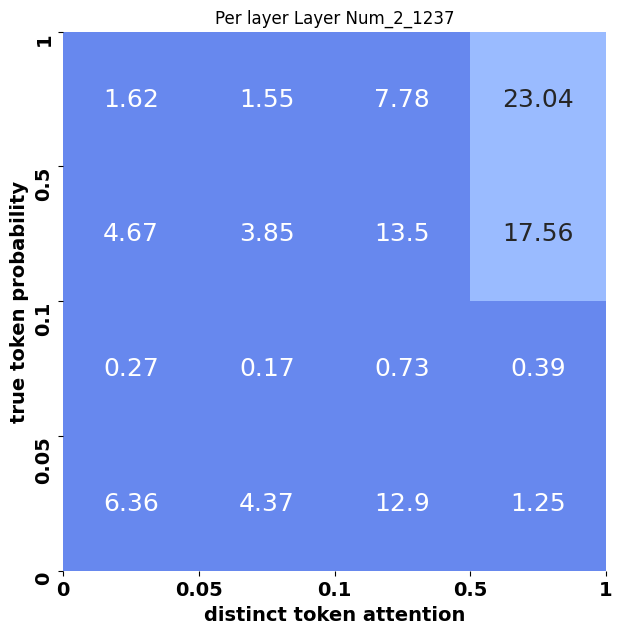

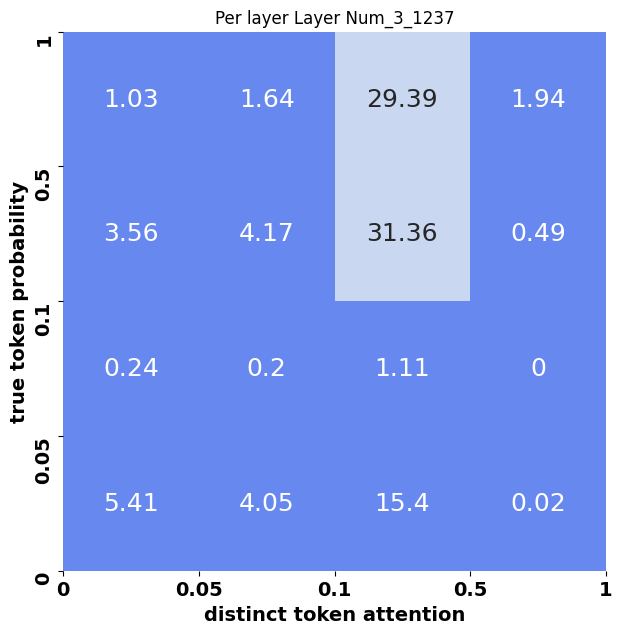

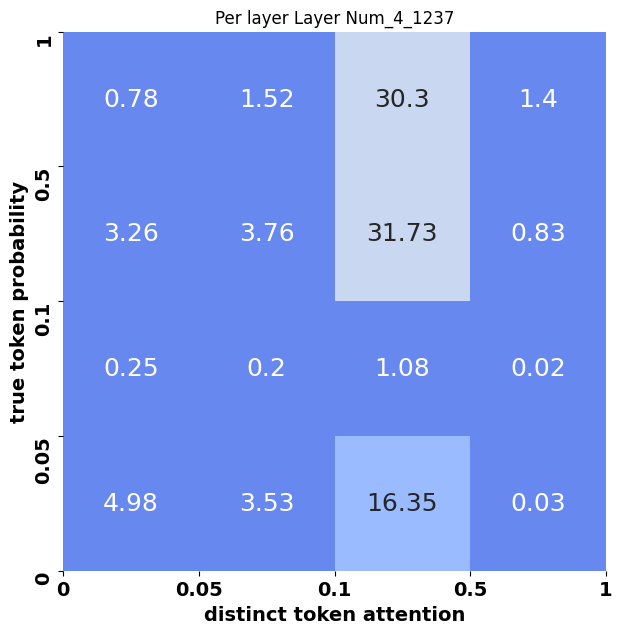

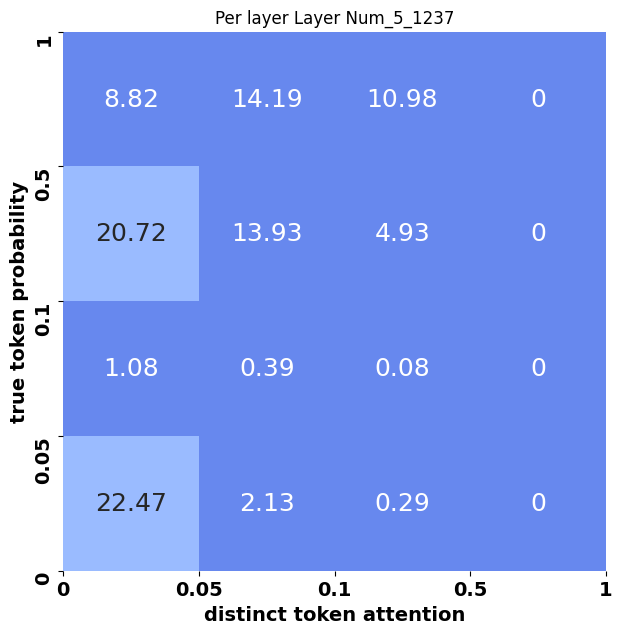

Initializing baseline model instance...1238
Initializing token embeddings with GloVe...
✓ Token embeddings initialized with GloVe
Baseline model loaded.


100%|██████████| 5928/5928 [20:04<00:00,  4.92it/s]


Baseline Validation Results...1238
Rollout:           0.1038
Layer-Avg:         0.1960
Max-Pooling:       0.6264
Comprehensiveness: 0.5571 (higher = better)
Sufficiency:       0.5965 (lower = better)


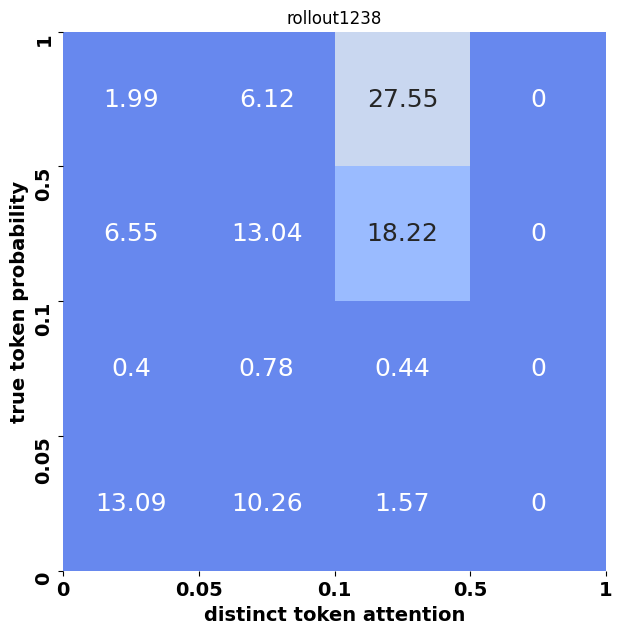

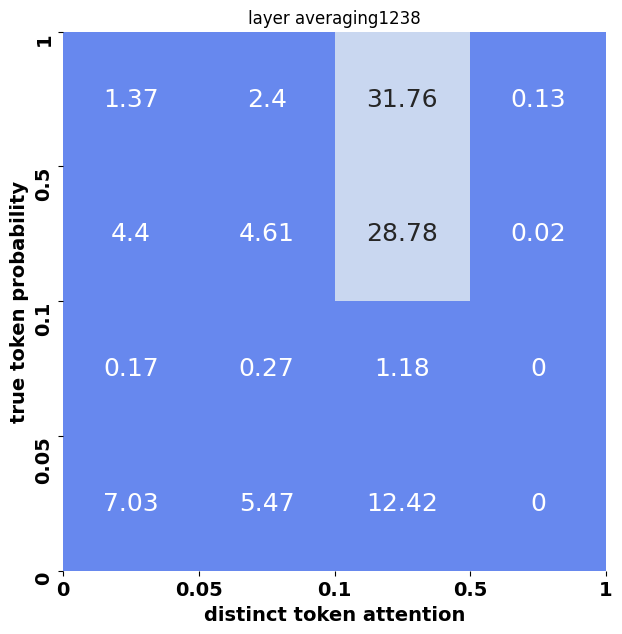

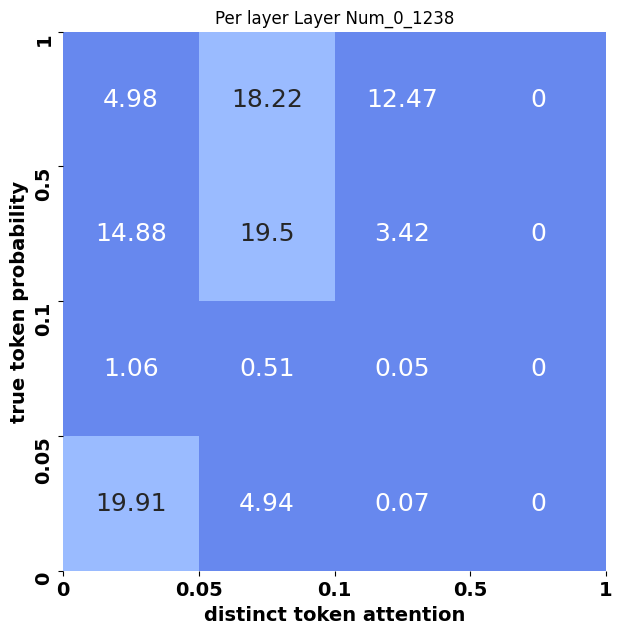

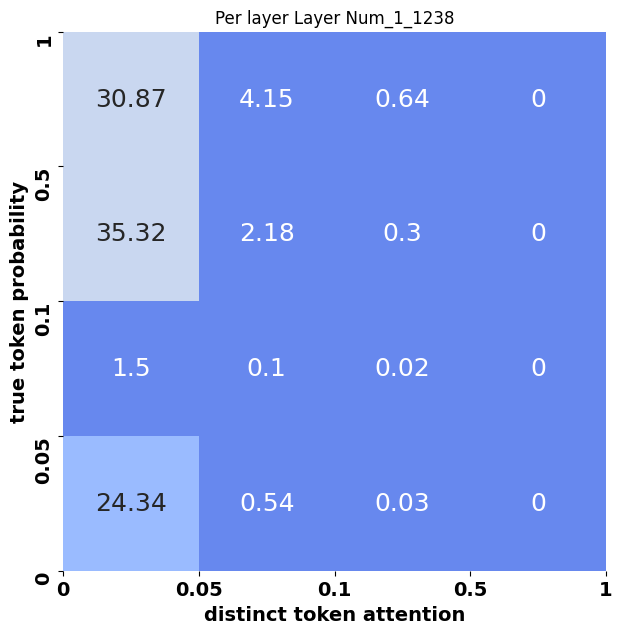

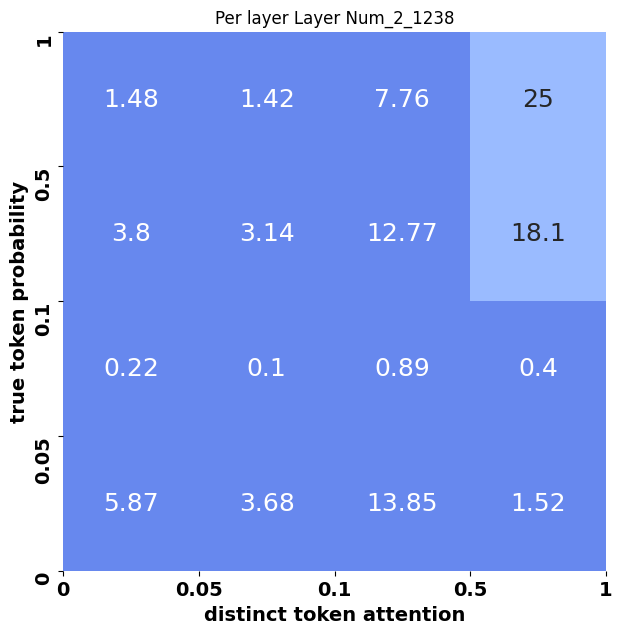

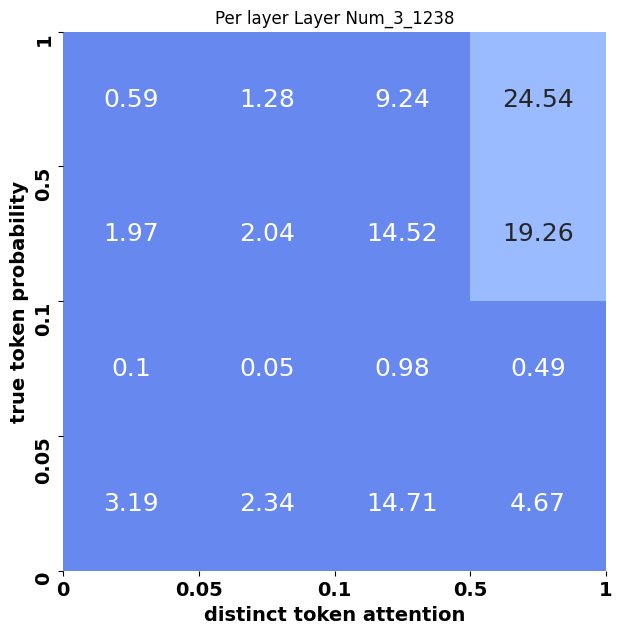

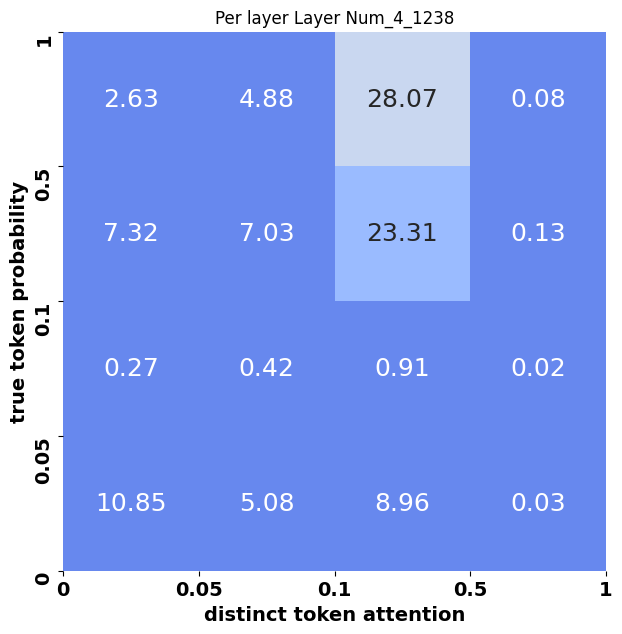

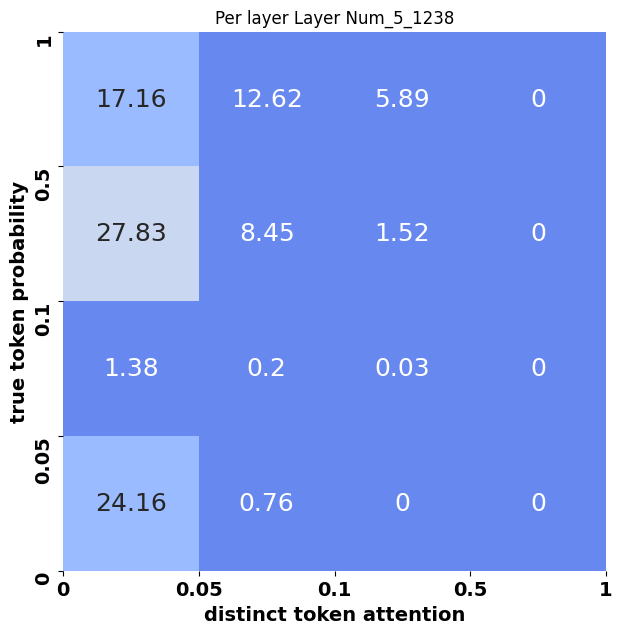

In [ ]:
seeds_list = [1234, 1235,1236, 1237, 1238]

DEV_JSON = "dev-v2.0.json" #"dev-v2.0.json"
print("Loading tokenizer...")
tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token
DROPOUT = 0.2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Loading dataset...")
val_dataset = load_squad_with_spans(DEV_JSON)
print(f"Loaded {len(val_dataset)} examples (focus spans included)")
glove_file = download_and_extract_glove()
pretrained_embeddings = load_glove_embeddings(glove_file, tokenizer, D_MODEL)



for nseed in seeds_list:
    BASELINE_CKPT = """/content/best_qk_"""+str(nseed)+""".pt""" #"best_qk.pt"  #"best_baseline.pt"  #  "best_qk.pt"
    model_kwargs = dict(vocab_size=tokenizer.vocab_size,
                        d_model=D_MODEL, n_heads=N_HEADS,
                        n_layers=N_LAYERS, d_ff=D_FF,
                        max_seq_len=MAX_SEQ_LEN,
                        dropout=DROPOUT,pretrained_embeddings=pretrained_embeddings)
    print("Initializing baseline model instance..."+str(nseed))
    baseline = GPTAnswerGenerator(**model_kwargs).to(device)
    baseline_ckpt = torch.load(BASELINE_CKPT, map_location=device)
    baseline.load_state_dict(baseline_ckpt["model"])
    print("Baseline model loaded.")



    # Usage in your main loop:
    n_samples = 6000
    items = val_dataset.data[:n_samples]

    Attn_Scores_Rollout = []
    Attn_Scores_LayerAvg = []
    Attn_Scores_MaxPool = []
    Comprehensiveness_Scores = []
    Sufficiency_Scores = []

    Prediction_Scores = []
    # Per-layer attention scores: list of length N_LAYERS, each is a list over datapoints
    Attn_Scores_PerLayer = [[] for _ in range(N_LAYERS)]

    for item in tqdm(items):
        question = item["question"]
        context = item["context"]
        gold = item["answer"]
        answer_positions, ids = get_answer_token_positions(question, context,
                                                           item["answer_start"],
                                                           item["answer_end"], tokenizer)
        pred, attn_steps, prob_steps = generate_faithful(baseline, tokenizer, context, question, device)

        if not attn_steps:
            continue

        # Compute attention mass metrics
        rollout_mass, layer_avg_mass, max_pool_mass, rollout_attn_probs, per_layer_means = attention_mass(
            attn_steps, answer_positions, alpha=0.5
        )

        # Prediction score for the *correct* output (same for all attention methods)
        pred_score = compute_prediction_score(baseline, tokenizer, context, question, gold, device)
        Prediction_Scores.append(pred_score)

        # Store per-layer attention masses (one value per layer for this datapoint)
        for li, mval in enumerate(per_layer_means):
            if li < len(Attn_Scores_PerLayer):
                Attn_Scores_PerLayer[li].append(mval)

        # Compute comprehensiveness and sufficiency
        comp, suff = compute_comprehensiveness_sufficiency(
            baseline, tokenizer, context, question, device,
            attn_steps, prob_steps, ids, rollout_attn_probs, k_percent=5
        )

        Attn_Scores_Rollout.append(rollout_mass)
        Attn_Scores_LayerAvg.append(layer_avg_mass)
        Attn_Scores_MaxPool.append(max_pool_mass)
        Comprehensiveness_Scores.append(comp)
        Sufficiency_Scores.append(suff)

    # Print results
    print("Baseline Validation Results..."+str(nseed))
    print(f"Rollout:           {np.mean(Attn_Scores_Rollout):.4f}")
    print(f"Layer-Avg:         {np.mean(Attn_Scores_LayerAvg):.4f}")
    print(f"Max-Pooling:       {np.mean(Attn_Scores_MaxPool):.4f}")
    print(f"Comprehensiveness: {np.mean(Comprehensiveness_Scores):.4f} (higher = better)")
    print(f"Sufficiency:       {np.mean(Sufficiency_Scores):.4f} (lower = better)")


    plot_heatmap(Attn_Scores_Rollout,Prediction_Scores,
                 name="rollout"+str(nseed))
    plot_heatmap(Attn_Scores_LayerAvg,Prediction_Scores,
                 name="layer averaging"+str(nseed))

    for l in range(len(Attn_Scores_PerLayer)):
      plot_heatmap(Attn_Scores_PerLayer[l],Prediction_Scores,
                   name="Per layer Layer Num_" +str(l)+"_"+str(nseed))





In [ ]:
seeds_list = [1234, 1235,1236, 1237, 1238]

DEV_JSON = "train-v2.0.json" #"dev-v2.0.json"


print("Loading tokenizer...")
tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token
DROPOUT = 0.2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Loading dataset...")
val_dataset = load_squad_with_spans(DEV_JSON)
print(f"Loaded {len(val_dataset)} examples (focus spans included)")
glove_file = download_and_extract_glove()
pretrained_embeddings = load_glove_embeddings(glove_file, tokenizer, D_MODEL)



for nseed in seeds_list:
    BASELINE_CKPT = """/content/best_baseline_"""+str(nseed)+""".pt""" #"best_qk.pt"  #"best_baseline.pt"  #  "best_qk.pt"
    model_kwargs = dict(vocab_size=tokenizer.vocab_size,
                        d_model=D_MODEL, n_heads=N_HEADS,
                        n_layers=N_LAYERS, d_ff=D_FF,
                        max_seq_len=MAX_SEQ_LEN,
                        dropout=DROPOUT,pretrained_embeddings=pretrained_embeddings)
    print("Initializing baseline model instance..."+str(nseed))
    baseline = GPTAnswerGenerator(**model_kwargs).to(device)
    baseline_ckpt = torch.load(BASELINE_CKPT, map_location=device)
    baseline.load_state_dict(baseline_ckpt["model"])
    print("Baseline model loaded.")



    # Usage in your main loop:
    n_samples = 40000
    items = val_dataset.data[:n_samples]

    Attn_Scores_Rollout = []
    Attn_Scores_LayerAvg = []
    Attn_Scores_MaxPool = []
    Comprehensiveness_Scores = []
    Sufficiency_Scores = []

    Prediction_Scores = []
    # Per-layer attention scores: list of length N_LAYERS, each is a list over datapoints
    Attn_Scores_PerLayer = [[] for _ in range(N_LAYERS)]

    for item in tqdm(items):
        question = item["question"]
        context = item["context"]
        gold = item["answer"]
        answer_positions, ids = get_answer_token_positions(
            question, context, item["answer_start"], item["answer_end"], tokenizer
        )
        pred, attn_steps, prob_steps = generate_faithful(baseline, tokenizer, context, question, device)

        if not attn_steps:
            continue

        # Compute attention mass metrics
        rollout_mass, layer_avg_mass, max_pool_mass, rollout_attn_probs, per_layer_means = attention_mass(
            attn_steps, answer_positions, alpha=0.5
        )

        # Prediction score for the *correct* output (same for all attention methods)
        pred_score = compute_prediction_score(baseline, tokenizer, context, question, gold, device)
        Prediction_Scores.append(pred_score)

        # Store per-layer attention masses (one value per layer for this datapoint)
        for li, mval in enumerate(per_layer_means):
            if li < len(Attn_Scores_PerLayer):
                Attn_Scores_PerLayer[li].append(mval)

        # Compute comprehensiveness and sufficiency
        comp, suff = compute_comprehensiveness_sufficiency(
            baseline, tokenizer, context, question, device,
            attn_steps, prob_steps, ids, rollout_attn_probs, k_percent=5
        )

        Attn_Scores_Rollout.append(rollout_mass)
        Attn_Scores_LayerAvg.append(layer_avg_mass)
        Attn_Scores_MaxPool.append(max_pool_mass)
        Comprehensiveness_Scores.append(comp)
        Sufficiency_Scores.append(suff)

    # Print results
    print("Baseline Validation Results..."+str(nseed))
    print(f"Rollout:           {np.mean(Attn_Scores_Rollout):.4f}")
    print(f"Layer-Avg:         {np.mean(Attn_Scores_LayerAvg):.4f}")
    print(f"Max-Pooling:       {np.mean(Attn_Scores_MaxPool):.4f}")
    print(f"Comprehensiveness: {np.mean(Comprehensiveness_Scores):.4f} (higher = better)")
    print(f"Sufficiency:       {np.mean(Sufficiency_Scores):.4f} (lower = better)")


    plot_heatmap(Attn_Scores_Rollout,Prediction_Scores,
                 name="rollout"+str(nseed))
    plot_heatmap(Attn_Scores_LayerAvg,Prediction_Scores,
                 name="layer averaging"+str(nseed))

    for l in range(len(Attn_Scores_PerLayer)):
      plot_heatmap(Attn_Scores_PerLayer[l],Prediction_Scores,
                   name="Per layer Layer Num_" +str(l)+"_"+str(nseed))


Loading tokenizer...
Loading dataset...
Loaded 86821 examples (focus spans included)
✓ GloVe embeddings found: glove.6B.300d.txt

LOADING GLOVE EMBEDDINGS
Reading GloVe file (this takes ~1 minute)...


Loading GloVe: 400001it [00:35, 11150.87it/s]                            


✓ Loaded 400,001 GloVe vectors
Matching tokenizer vocabulary with GloVe...


Matching: 100%|██████████| 50257/50257 [00:00<00:00, 426399.47it/s]

✓ Matched 43,058/50,257 tokens (85.7%)



Initializing baseline model instance...1234
Initializing token embeddings with GloVe...
✓ Token embeddings initialized with GloVe
Baseline model loaded.


 84%|████████▎ | 33467/40000 [1:25:41<33:44,  3.23it/s]

In [ ]:
seeds_list = [ 1237, 1238] # [1234, 1235,1236]

DEV_JSON = "train-v2.0.json" #"dev-v2.0.json"
print("Loading tokenizer...")
tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token
DROPOUT = 0.2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Loading dataset...")
val_dataset = load_squad_with_spans(DEV_JSON)
print(f"Loaded {len(val_dataset)} examples (focus spans included)")
glove_file = download_and_extract_glove()
pretrained_embeddings = load_glove_embeddings(glove_file, tokenizer, D_MODEL)



for nseed in seeds_list:
    BASELINE_CKPT = """/home/cs22d010/Squad_QA/Squad_Results/Rebuiding-From-Scratch/best_qk_"""+str(nseed)+""".pt""" #"best_qk.pt"  #"best_baseline.pt"  #  "best_qk.pt"
    model_kwargs = dict(vocab_size=tokenizer.vocab_size,
                        d_model=D_MODEL, n_heads=N_HEADS,
                        n_layers=N_LAYERS, d_ff=D_FF,
                        max_seq_len=MAX_SEQ_LEN,
                        dropout=DROPOUT,pretrained_embeddings=pretrained_embeddings)
    print("Initializing baseline model instance..."+str(nseed))
    baseline = GPTAnswerGenerator(**model_kwargs).to(device)
    baseline_ckpt = torch.load(BASELINE_CKPT, map_location=device)
    baseline.load_state_dict(baseline_ckpt["model"])
    print("Baseline model loaded.")



    # Usage in your main loop:
    n_samples = 40000
    items = val_dataset.data[:n_samples]

    Attn_Scores_Rollout = []
    Attn_Scores_LayerAvg = []
    Attn_Scores_MaxPool = []
    Comprehensiveness_Scores = []
    Sufficiency_Scores = []

    for item in tqdm(items):
        question = item["question"]
        context = item["context"]
        gold = item["answer"]
        answer_positions, ids = get_answer_token_positions(
            question, context, item["answer_start"], item["answer_end"], tokenizer
        )
        pred, attn_steps, prob_steps = generate_faithful(baseline, tokenizer, context, question, device)

        if not attn_steps:
            continue

        # Compute attention mass metrics
        rollout_mass, layer_avg_mass, max_pool_mass, rollout_attn_probs = attention_mass(
            attn_steps, answer_positions, alpha=0.5
        )

        # Compute comprehensiveness and sufficiency
        comp, suff = compute_comprehensiveness_sufficiency(
            baseline, tokenizer, context, question, device,
            attn_steps, prob_steps, ids, rollout_attn_probs, k_percent=5
        )

        Attn_Scores_Rollout.append(rollout_mass)
        Attn_Scores_LayerAvg.append(layer_avg_mass)
        Attn_Scores_MaxPool.append(max_pool_mass)
        Comprehensiveness_Scores.append(comp)
        Sufficiency_Scores.append(suff)

    # Print results
    print("Proposed Train Results..."+str(nseed))
    print(f"Rollout:           {np.mean(Attn_Scores_Rollout):.4f}")
    print(f"Layer-Avg:         {np.mean(Attn_Scores_LayerAvg):.4f}")
    print(f"Max-Pooling:       {np.mean(Attn_Scores_MaxPool):.4f}")
    print(f"Comprehensiveness: {np.mean(Comprehensiveness_Scores):.4f} (higher = better)")
    print(f"Sufficiency:       {np.mean(Sufficiency_Scores):.4f} (lower = better)")

In [ ]:
Rollout:           0.1017
Layer-Avg:         0.2027
Max-Pooling:       0.6363
Comprehensiveness: 0.5624 (higher = better)
Sufficiency:       0.6289 (lower = better)
Initializing baseline model instance...1235
Initializing token embeddings with GloVe...
✓ Token embeddings initialized with GloVe
Baseline model loaded.
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40000/40000 [1:30:25<00:00,  7.37it/s]
Proposed Train Results...1235
Rollout:           0.0982
Layer-Avg:         0.2071
Max-Pooling:       0.6246
Comprehensiveness: 0.5539 (higher = better)
Sufficiency:       0.5638 (lower = better)
Initializing baseline model instance...1236
Initializing token embeddings with GloVe...
✓ Token embeddings initialized with GloVe
Baseline model loaded.
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40000/40000 [1:19:14<00:00,  8.41it/s]
Proposed Train Results...1236
Rollout:           0.0997
Layer-Avg:         0.2068
Max-Pooling:       0.6767
Comprehensiveness: 0.5409 (higher = better)
Sufficiency:       0.5747 (lower = better)
Proposed Train Results...1237
Rollout:           0.0846
Layer-Avg:         0.1872
Max-Pooling:       0.5931
Comprehensiveness: 0.5021 (higher = better)
Sufficiency:       0.7150 (lower = better)
Proposed Train Results...1238
Rollout:           0.1046
Layer-Avg:         0.2042
Max-Pooling:       0.6477
Comprehensiveness: 0.5697 (higher = better)
Sufficiency:       0.6105 (lower = better)

| | F1 Score| Comprehensiveness | Sufficiency |Attn Score| Entropy | KL Divergence| Rollout Recall| Avg Recall|
|- |--       | --          | --          | --       | --      |--            | --            | -         |
| Validation(baseline)| 0.5703, 0.5712,0.5514,0.570,0.5929 |  |   | 0.137,0.1456,0.138,0.1404,0.150 | 4.80 4.70,4.682,4.7360,4.64  | 1.71,1.81,1.83, 1.77, 1.86 |0.00056, 0.00056,0.00057,0.00057,0.00065 | 0.465, 0.477,0.4522,0.467,0.4926|
| Validation (Proposed)| 0.5815, 0.59, 0.61,0.569,0.602 | |  | 0.244, 0.254,0.250,0.222,0.246 | 4.07, 3.98,4.012, 4.31,3.94 | 2.43, 2.53 2.50, 2.19, 2.56 | 0.0067, 0.008, 0.004, 0.025, 0.013 | 0.573, 0.55,0.614, 0.573 ,0.583 |

In [ ]:
np.mean(Attn_Scores)

In [ ]:
np.mean(Attn_Entropy)

In [ ]:
np.mean(KL_Div_Scores)

In [ ]:
np.mean(Rollout_Recall)

In [ ]:
np.mean(Avg_Recall)

In [ ]:
np.mean(F1_Scores),

In [ ]:
np.mean(Comprehensivenes_Scores),

In [ ]:
np.mean(Sufficiency_Scores)

In [ ]:
'''
Proposed’s attention might highlight true evidence tokens (helpful for interpretability and human
understanding) but those alone may not let the model copy
the answer verbatim — which raises sufficiency but
improves other faithfulness indicators
'''

In [ ]:
# len(instance_probs), len(attention_scores_instance),attention_scores_instance.shape


In [ ]:
# print(np.mean(attention_scores_instance,axis=0))

In [ ]:
# print(np.mean(attention_scores_instance,axis=0))

In [ ]:
# from matplotlib import pyplot as plt
# from matplotlib.colors import ListedColormap
# import seaborn as sns



# for layer in range(6):
#     bin_edges = [np.array([0, 0.05, 0.1, 0.5, 1]), np.array([0, 0.05, 0.1, 0.5,  1])]



#     hist,_,_= np.histogram2d( np.array(attention_scores_instance)[:,layer].astype(float),
#                              np.array(instance_probs).astype(float), bins=bin_edges)
#     num = (hist.sum()/100)
#     hist = hist/num
#     # Assuming `mean_hist_norm` and `var_hist_norm` are your 2D arrays of the same shape
#     # If you prefer to show std instead of variance in the annotation, convert variance to std:


#     # Create annotation labels with both mean and std (formatted as strings)
#     annot_array = np.empty_like(hist, dtype=object)


#     for i in range(hist.shape[0]):
#         for j in range(hist.shape[1]):
#             annot_array[i, j] = f"{hist[i, j]:.1f}"#\n(±{std_hist_norm[i, j]:.1f})"  # mean ± std

#     # # Define tick positions for edges of bins (for correct labeling)
#     x_edges = np.array([0, 0.05, 0.1, 0.5, 1])
#     y_edges = np.array([0, 0.05, 0.1, 0.5, 1])
#     xtick_positions = np.arange(len(x_edges) - 1) + 1.0  # Right edges
#     ytick_positions = np.arange(len(y_edges) - 1) + 1.0  # Top edges

#     # Plot heatmap for mean values (color intensity)
#     plt.figure(figsize=(6, 6))
#     ax = sns.heatmap(hist.T, annot=annot_array.T, cmap=sns.color_palette("coolwarm"),
#                       annot_kws={"size":18}, cbar=False, vmin=5, vmax=70,fmt="")

#     # Adjust tick positions for x and y axes (move them to the edges)
#     ax.set_xticks(xtick_positions)
#     ax.set_yticks(ytick_positions)

#     # Set the labels for ticks (x and y edges)
#     ax.set_xticklabels(x_edges[1:])
#     ax.set_yticklabels(y_edges[1:])

#     # # Make the tick labels bold
#     ax.tick_params(axis='x', labelsize=14)  # Bold x-axis labels
#     ax.tick_params(axis='y', labelsize=14)  # Bold y-axis labels


#     # Invert y-axis to align with typical heatmap style
#     ax.invert_yaxis()

#     # Labels and title
#     plt.xlabel(r"Distinct Token Attention", fontweight="bold", fontsize=16)
#     plt.ylabel(r"Relevant Token Probability", fontweight="bold", fontsize=16)
#     #plt.title("Mean (±Std Dev) Heatmap")

#     # # Save the figure
#     plt.savefig("Saved_Data/Baseline_squad_train_layer_" +str(layer)+"_.pdf", bbox_inches='tight')
#     plt.show()

In [ ]:
# (8, 68, 3054, 2633, 572, 0), [0.01102379 0.01735731 0.12572766 0.1141563  0.04115164 0.01294783]

# (21, 2760, 1267, 176, 0, 0),   [0.00595229 0.10576697 0.07610722 0.02425341 0.00664042 0.00879594]